In [31]:
from pathlib import Path
import sys

ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch

from tools_ahrs import plot

from kaist_dataset import load_imus
from kaist_dataset.lidar import load_lidar_relative_poses

from obscalib.augmentations.calibration_event import CalibrationEventSampler
from obscalib.augmentations.config import AugmentationConfig, CalibrationEventConfig, FrameRandomizationConfig, NoiseAugmentationConfig, PerturbationMagnitudeConfig, PriorPerturbationConfig, SamplingRateAugmentationConfig, SE3NoiseConfig, VectorNoiseConfig
from obscalib.augmentations.frame_randomization import SensorFrameRandomizer
from obscalib.augmentations.noise import MeasurementNoiseAugmenter
from obscalib.augmentations.prior_perturbation import CalibrationPriorPerturber
from obscalib.augmentations.profiles import TransitionProfile
from obscalib.augmentations.rendering import CalibrationEventRenderer
from obscalib.augmentations.sampling_rate import SamplingRateAugmenter
from obscalib.augmentations.structures import CalibrationTrajectory

from obscalib.data.adapter import PreprocessedCalibration, PreprocessedSensorStream, build_window_samples_from_preprocessed
from obscalib.data.collation import collate_windows
from obscalib.data.structures import GeometryType, MeasurementType, SensorStreamBatch, WindowBatch
from obscalib.config import WindowingConfig
from obscalib.geometry.lie import se3_log


DTYPE = torch.float64
SEED = 322

print("Repository root:", ROOT)

Repository root: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib


In [32]:
KAIST_DATASETS_ROOT = Path("/mnt/d/Downloads/MobRobLab/KAISTDataset")
DATASET_NAME = "Urban16"
DATASET_SLUG = DATASET_NAME.lower()

DATASET_ROOT = KAIST_DATASETS_ROOT / DATASET_NAME
SENSOR_DATA_ROOT = DATASET_ROOT / f"{DATASET_SLUG}_data" / DATASET_SLUG / "sensor_data"

LIDAR_MAP_POSE_CSV = Path("/home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv")

# Keep native IMU timing here. Set to 100.0 only if you deliberately want the old notebook's preprocessing before augmentation.
LOAD_IMU_FREQUENCY_HZ = None
MAX_IMU_FILES = None

WINDOW_DURATION_S = 10.0

# Move this farther into the common sensor support if the first interval happens to be unusually static.
WINDOW_OFFSET_FROM_COMMON_START_S = 60.0

print("Dataset root:", DATASET_ROOT)
print("Sensor data root:", SENSOR_DATA_ROOT)
print("LiDAR map-pose CSV:", LIDAR_MAP_POSE_CSV)

Dataset root: /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16
Sensor data root: /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_data/urban16/sensor_data
LiDAR map-pose CSV: /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv


In [33]:
imu_streams = load_imus(SENSOR_DATA_ROOT, target_frequency_hz=LOAD_IMU_FREQUENCY_HZ, max_files=MAX_IMU_FILES)

if not imu_streams:
    raise ValueError(f"No KAIST IMU streams were found below {SENSOR_DATA_ROOT}")

primary_imu_name = list(imu_streams.keys())[0]
primary_imu = imu_streams[primary_imu_name]

lidar = load_lidar_relative_poses(LIDAR_MAP_POSE_CSV)

imu_dt = np.diff(primary_imu.timestamps_s)
lidar_dt = np.diff(lidar.scan_timestamps_s)

imu_frequency_hz = 1.0 / np.median(imu_dt)
lidar_frequency_hz = 1.0 / np.median(lidar_dt)

print("Primary IMU:", primary_imu_name)
print("IMU samples:", len(primary_imu.timestamps_s))
print("IMU median frequency [Hz]:", imu_frequency_hz)
print()
print("LiDAR absolute scans:", len(lidar.scan_timestamps_s))
print("LiDAR relative poses:", len(lidar.relative_poses_se3))
print("LiDAR median scan frequency [Hz]:", lidar_frequency_hz)
print()
print("IMU time support:", primary_imu.timestamps_s[0], "...", primary_imu.timestamps_s[-1])
print("LiDAR time support:", lidar.scan_timestamps_s[0], "...", lidar.scan_timestamps_s[-1])

Primary IMU: sensor_data_xsens_imu
IMU samples: 449215
IMU median frequency [Hz]: 100.00247961470602

LiDAR absolute scans: 37704
LiDAR relative poses: 37703
LiDAR median scan frequency [Hz]: 10.000009536752259

IMU time support: 1524205092.9013677 ... 1524209584.8480525
LiDAR time support: 1524205126.62 ... 1524209584.81


In [34]:
##################################################
# Common calibration frame
##################################################
# For this experiment:
#
#     W := KAIST body / vehicle frame
#
# Therefore CalibrationState.transform is:
#
#     IMU   -> T_B_I
#     LiDAR -> T_B_L
##################################################

T_B_L = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [ 0.486485, -0.711672,  0.506809,  0.397052],
    [-0.706447,  0.0208933, 0.707457,  1.90953],
    [ 0.0,       0.0,       0.0,       1.0],
], dtype=float)

T_I_B = np.array([
    [1.0, 0.0, 0.0, -0.07],
    [0.0, 1.0, 0.0,  0.0],
    [0.0, 0.0, 1.0,  1.7],
    [0.0, 0.0, 0.0,  1.0],
], dtype=float)

T_B_I = np.linalg.inv(T_I_B)

streams = {
    "gyro": PreprocessedSensorStream(
        values=primary_imu.gyro_radps,
        timestamps_s=primary_imu.timestamps_s,
        measurement_type=MeasurementType.IMU_GYROSCOPE,
        geometry_type=GeometryType.VECTOR,
        calibration_key="imu",
    ),
    "accel": PreprocessedSensorStream(
        values=primary_imu.accel_mps2,
        timestamps_s=primary_imu.timestamps_s,
        measurement_type=MeasurementType.IMU_ACCELEROMETER,
        geometry_type=GeometryType.VECTOR,
        calibration_key="imu",
    ),
    "lidar": PreprocessedSensorStream(
        values=lidar.relative_poses_se3,
        timestamps_s=lidar.scan_timestamps_s[1:],
        interval_start_timestamps_s=lidar.scan_timestamps_s[:-1],
        measurement_type=MeasurementType.LIDAR_POSE,
        geometry_type=GeometryType.SE3,
        calibration_key="lidar",
    ),
}

current_calibration = {
    "imu": PreprocessedCalibration(transform=T_B_I, time_offset_s=0.0),
    "lidar": PreprocessedCalibration(transform=T_B_L, time_offset_s=0.0),
}

common_start_time = max(primary_imu.timestamps_s[0], lidar.scan_timestamps_s[0])
visualization_start_time = common_start_time + WINDOW_OFFSET_FROM_COMMON_START_S
visualization_end_time = visualization_start_time + WINDOW_DURATION_S

print("Visualization interval:", visualization_start_time, "...", visualization_end_time)

Visualization interval: 1524205186.62 ... 1524205196.62


In [35]:
windowing_config = WindowingConfig(
    window_duration_s=WINDOW_DURATION_S,
    window_stride_s=WINDOW_DURATION_S,
    max_samples_per_sensor=100_000,
)

window_samples = build_window_samples_from_preprocessed(
    streams,
    current_calibration,
    windowing_config=windowing_config,
    start_time=visualization_start_time,
    end_time=visualization_end_time,
    dtype=DTYPE,
    timestamp_dtype=torch.float64,
)

if len(window_samples) != 1:
    raise ValueError(f"Expected exactly one visualization window, received {len(window_samples)}.")

base_window = collate_windows([window_samples[0]])

for stream_key, stream in base_window.streams.items():
    print(
        stream_key,
        "valid samples =", int(stream.sample_mask[0].sum()),
        "value shape =", tuple(stream.values.shape),
        "interval-valued =", stream.interval_start_timestamps is not None,
    )

gyro valid samples = 1000 value shape = (1, 1000, 3) interval-valued = False
accel valid samples = 1000 value shape = (1, 1000, 3) interval-valued = False
lidar valid samples = 99 value shape = (1, 99, 4, 4) interval-valued = True


In [36]:
AXIS_NAMES = ("x", "y", "z")
SE3_COMPONENT_NAMES = ("phi_x", "phi_y", "phi_z", "rho_x", "rho_y", "rho_z")


def valid_stream_arrays(window: WindowBatch, stream_key: str, batch_index: int = 0):
    """Return one valid padded stream as NumPy arrays."""

    stream = window.streams[stream_key]
    mask = stream.sample_mask[batch_index]

    timestamps = stream.timestamps[batch_index, mask].detach().cpu().numpy()
    values = stream.values[batch_index, mask].detach().cpu().numpy()

    if stream.interval_start_timestamps is None:
        interval_start_timestamps = None
    else:
        interval_start_timestamps = stream.interval_start_timestamps[batch_index, mask].detach().cpu().numpy()

    return timestamps, values, interval_start_timestamps


def plot_vector_comparison(original_window: WindowBatch, modified_window: WindowBatch, stream_key: str, title: str, ylabel: str):
    """Plot x/y/z components of one vector stream before and after augmentation."""

    original_t, original_values, _ = valid_stream_arrays(original_window, stream_key)
    modified_t, modified_values, _ = valid_stream_arrays(modified_window, stream_key)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for axis_index, axis_name in enumerate(AXIS_NAMES):
        axes[axis_index].plot(original_t, original_values[:, axis_index], label="original")
        axes[axis_index].plot(modified_t, modified_values[:, axis_index], label="modified")
        axes[axis_index].set_ylabel(f"{ylabel} {axis_name}")
        axes[axis_index].grid(True)
        axes[axis_index].legend()

    axes[-1].set_xlabel("time from window start [s]")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def se3_values_to_tangent(values: np.ndarray) -> np.ndarray:
    """Convert a sequence of SE3 matrices to [phi, rho] vectors."""

    values_tensor = torch.as_tensor(values, dtype=DTYPE)
    return se3_log(values_tensor).detach().cpu().numpy()


def plot_se3_comparison(original_window: WindowBatch, modified_window: WindowBatch, stream_key: str, title: str):
    """Plot all six SE3 tangent components before and after augmentation."""

    original_t, original_values, _ = valid_stream_arrays(original_window, stream_key)
    modified_t, modified_values, _ = valid_stream_arrays(modified_window, stream_key)

    original_xi = se3_values_to_tangent(original_values)
    modified_xi = se3_values_to_tangent(modified_values)

    fig, axes = plt.subplots(6, 1, figsize=(14, 13), sharex=True)

    for component_index, component_name in enumerate(SE3_COMPONENT_NAMES):
        axes[component_index].plot(original_t, original_xi[:, component_index], label="original")
        axes[component_index].plot(modified_t, modified_xi[:, component_index], label="modified")
        axes[component_index].set_ylabel(component_name)
        axes[component_index].grid(True)
        axes[component_index].legend()

    axes[-1].set_xlabel("relative-pose interval end time [s]")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

def relative_se3_tangent_rate(window: WindowBatch, stream_key: str, batch_index: int = 0):
    """Convert relative SE3 measurements to approximate average tangent rates over their measurement intervals."""

    end_timestamps, values, start_timestamps = valid_stream_arrays(window, stream_key, batch_index=batch_index)

    if start_timestamps is None:
        raise ValueError(f"Stream {stream_key!r} does not contain interval start timestamps.")

    durations_s = end_timestamps - start_timestamps

    if np.any(durations_s <= 0.0):
        raise ValueError("Relative SE3 intervals must have positive duration.")

    xi = se3_values_to_tangent(values)
    xi_rate = xi / durations_s[:, None]
    midpoint_timestamps = 0.5 * (start_timestamps + end_timestamps)

    return midpoint_timestamps, xi_rate, durations_s


def plot_relative_se3_rate_comparison(original_window: WindowBatch, modified_window: WindowBatch, stream_key: str, title: str):
    """Compare relative SE3 motion after normalizing every increment by its actual interval duration."""

    original_t, original_rate, original_dt = relative_se3_tangent_rate(original_window, stream_key)
    modified_t, modified_rate, modified_dt = relative_se3_tangent_rate(modified_window, stream_key)

    fig, axes = plt.subplots(7, 1, figsize=(14, 15), sharex=True)

    for component_index, component_name in enumerate(SE3_COMPONENT_NAMES):
        axes[component_index].plot(original_t, original_rate[:, component_index], label="original")
        axes[component_index].plot(modified_t, modified_rate[:, component_index], label="modified")
        axes[component_index].set_ylabel(f"{component_name}/s")
        axes[component_index].grid(True)
        axes[component_index].legend()

    axes[-1].plot(original_t, original_dt, label="original")
    axes[-1].plot(modified_t, modified_dt, label="modified")
    axes[-1].set_ylabel("Δt [s]")
    axes[-1].set_xlabel("interval midpoint time [s]")
    axes[-1].grid(True)
    axes[-1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def canonicalize_vector(values: torch.Tensor, calibration_transform: torch.Tensor) -> torch.Tensor:
    """Apply the VECTOR convention v_W = R_WS v_S to row-wise measurements."""

    R_WS = calibration_transform[:3, :3]
    return values @ R_WS.transpose(-1, -2)


def canonicalize_relative_se3(values: torch.Tensor, calibration_transform: torch.Tensor) -> torch.Tensor:
    """Apply DeltaT_W = T_WS DeltaT_S T_WS^-1."""

    T_WS = calibration_transform
    T_SW = torch.linalg.inv(T_WS)
    return T_WS.unsqueeze(0) @ values @ T_SW.unsqueeze(0)


def print_calibration_state(label: str, state) -> None:
    xi = se3_log(state.transform)[0].detach().cpu().numpy()
    tau = float(state.time_offset[0, 0].detach().cpu())

    print(label)
    print("  xi  =", xi)
    print("  tau =", tau)


def realized_point_frequency(window: WindowBatch, stream_key: str) -> float:
    timestamps, _, _ = valid_stream_arrays(window, stream_key)

    if len(timestamps) < 2:
        return float("nan")

    return float(1.0 / np.median(np.diff(timestamps)))


def realized_interval_frequency(window: WindowBatch, stream_key: str) -> float:
    """Return the average realized interval rate over the complete valid support."""

    end_timestamps, _, start_timestamps = valid_stream_arrays(window, stream_key)

    if start_timestamps is None or len(end_timestamps) == 0:
        return float("nan")

    total_duration_s = end_timestamps[-1] - start_timestamps[0]

    if total_duration_s <= 0.0:
        return float("nan")

    return float(len(end_timestamps) / total_duration_s)

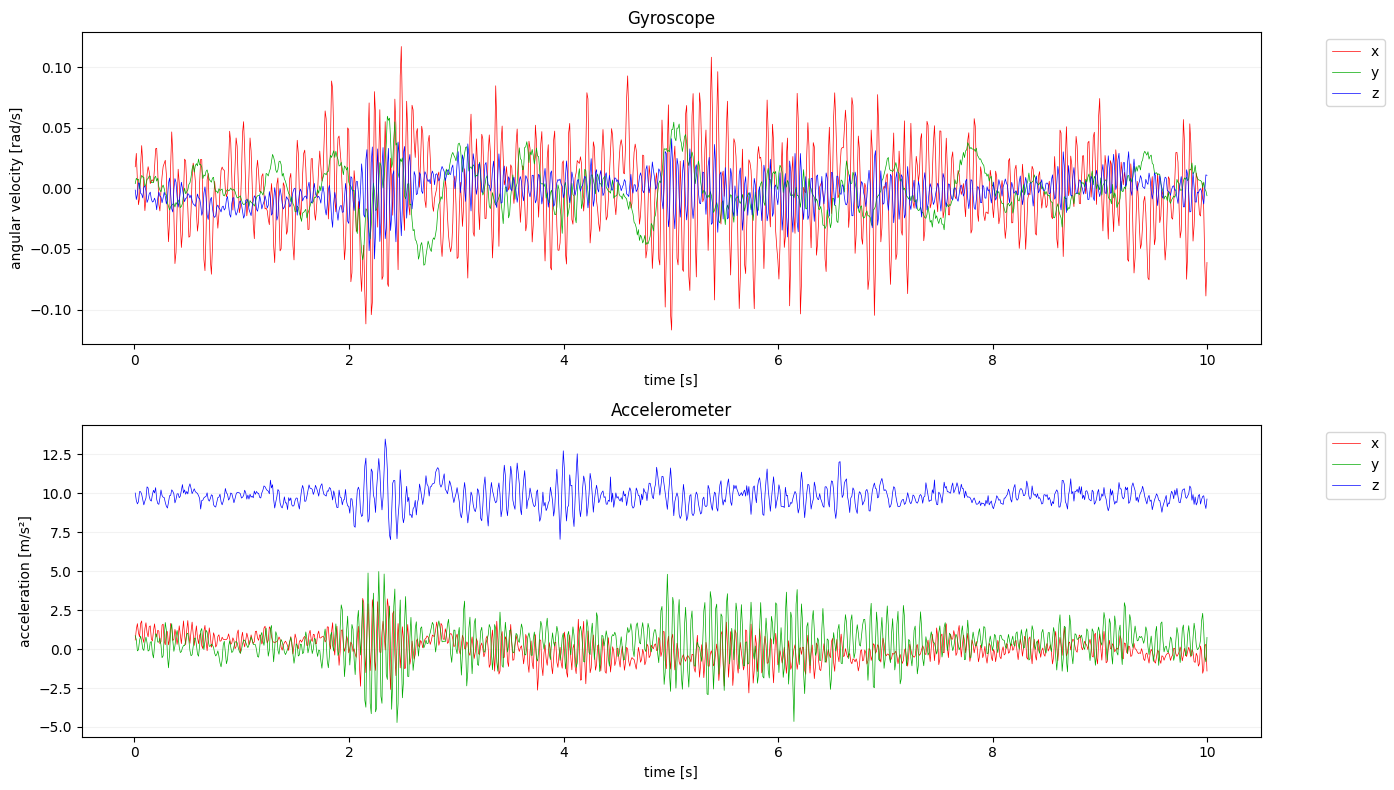

In [37]:
gyro_t, gyro_values, _ = valid_stream_arrays(base_window, "gyro")
accel_t, accel_values, _ = valid_stream_arrays(base_window, "accel")

plot(
    gyro_values,
    accel_values,
    title="Raw KAIST visualization window",
    subtitles=["Gyroscope", "Accelerometer"],
    labels=[["x", "y", "z"], ["x", "y", "z"]],
    ylabels=["angular velocity [rad/s]", "acceleration [m/s²]"],
    xlabels=["time [s]", "time [s]"],
    indices=np.stack((gyro_t, accel_t)),
    figsize=(14, 8),
)

# sampling-rate augmentation

Requested / recorded sampling frequencies:
  gyro: 97.148 Hz, applied=True
  accel: 97.148 Hz, applied=True
  lidar: 5.927 Hz, applied=True

Realized frequencies from resulting timestamps:
  gyro : 97.14773443237189 Hz
  accel: 97.14773443237189 Hz
  lidar: 5.905906041216679 Hz


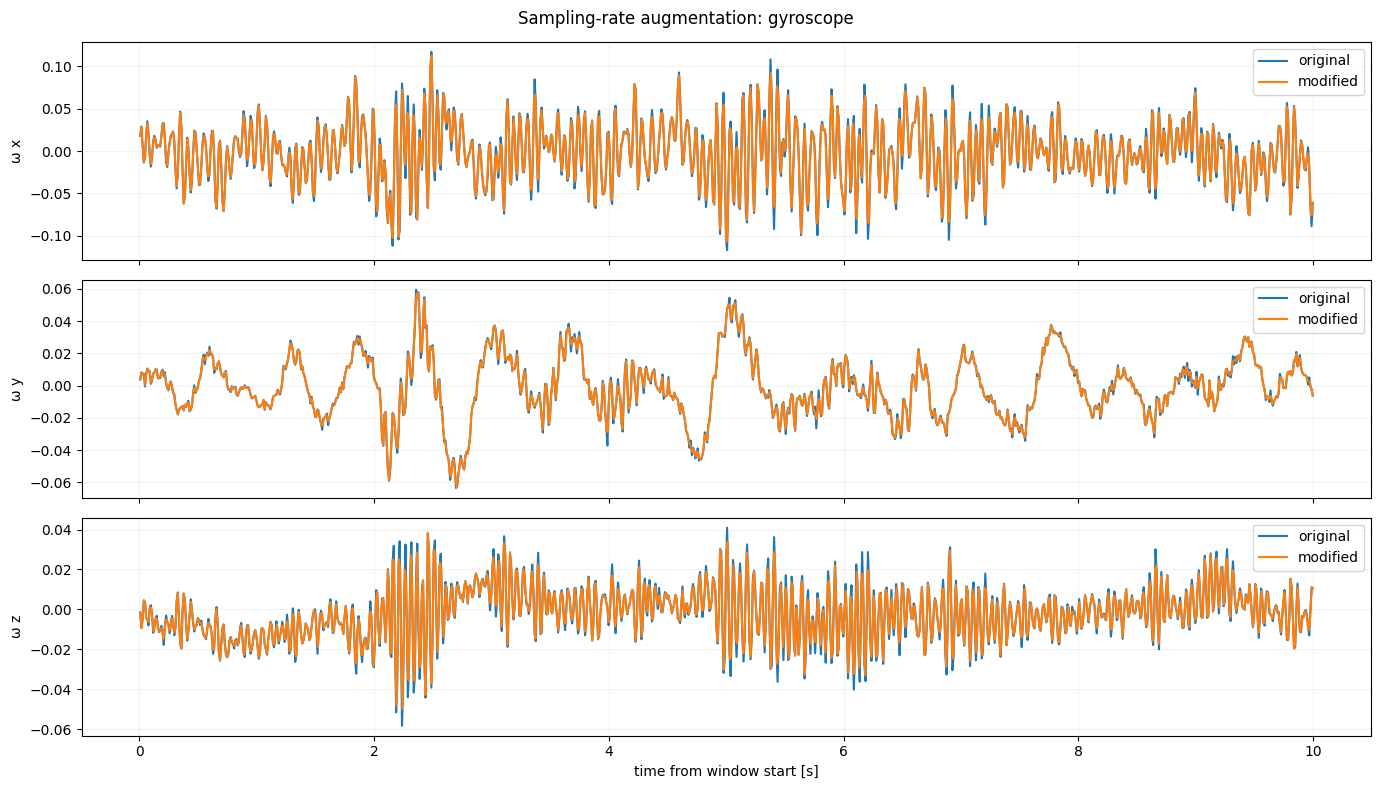

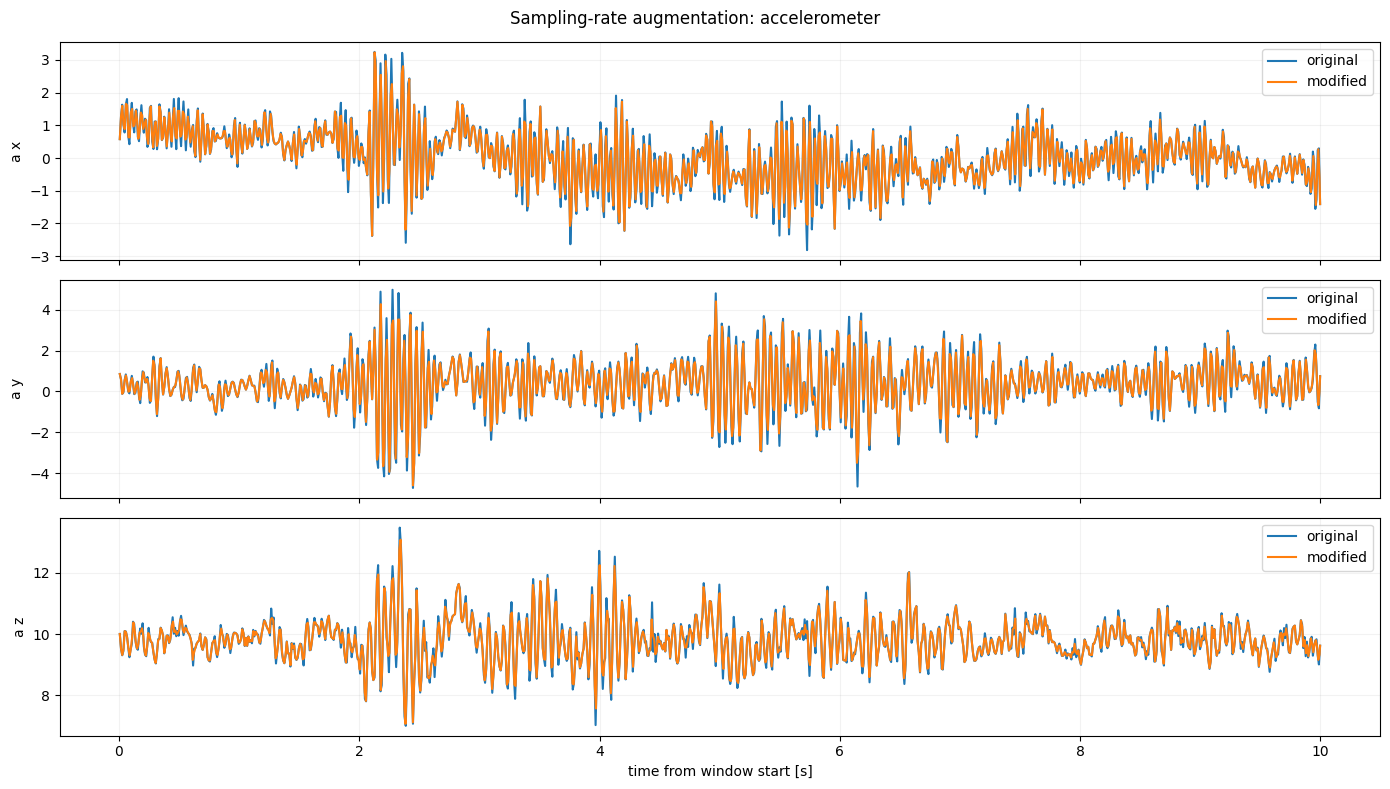

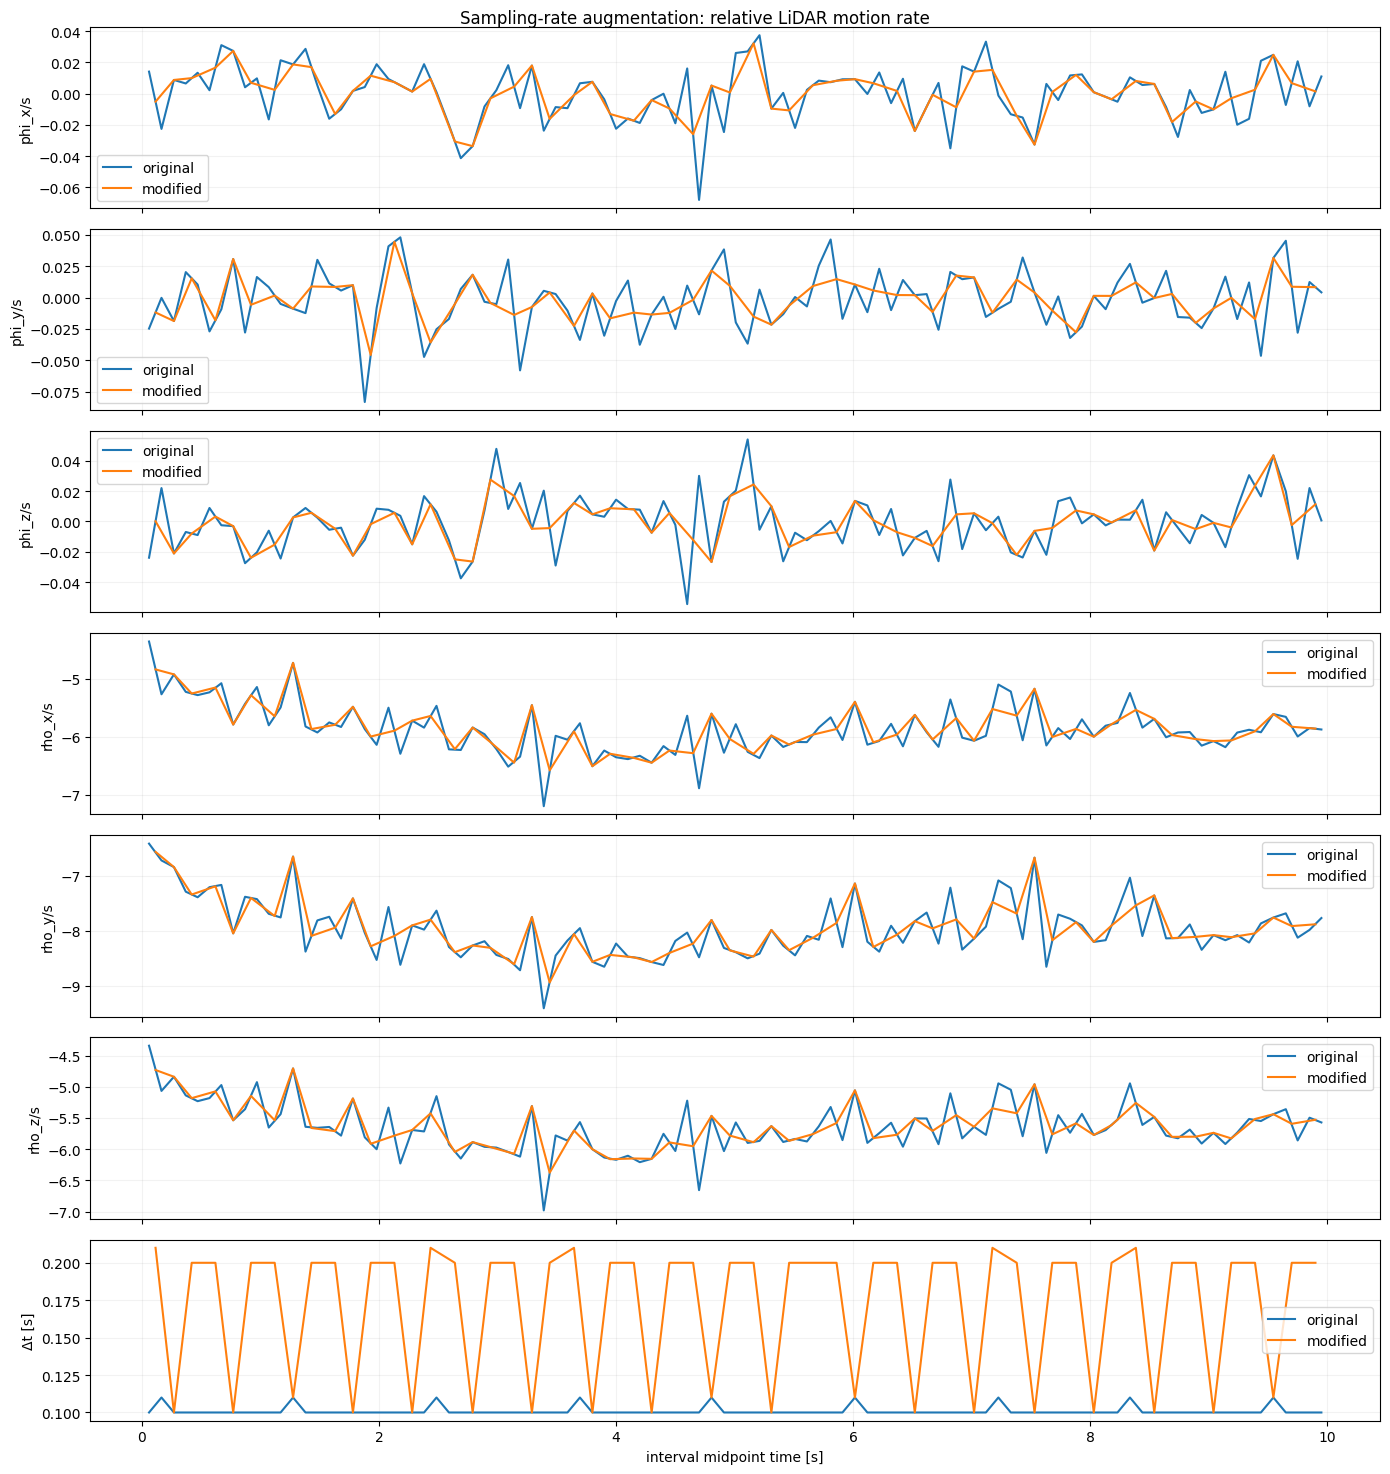

In [38]:
sampling_rate_augmenter = SamplingRateAugmenter(
    SamplingRateAugmentationConfig(
        enabled=True,
        minimum_imu_frequency_hz=40.0,
        minimum_lidar_frequency_hz=5.0,
        imu_probability=1.0,
        lidar_probability=1.0,
    )
)

sampling_generator = torch.Generator().manual_seed(SEED)

sampling_window, sampled_frequency_hz, sampling_applied = sampling_rate_augmenter(base_window, generator=sampling_generator)

print("Requested / recorded sampling frequencies:")
for stream_key, frequency in sampled_frequency_hz.items():
    print(f"  {stream_key}: {float(frequency[0, 0]):.3f} Hz, applied={bool(sampling_applied[stream_key][0, 0])}")

print()
print("Realized frequencies from resulting timestamps:")
print("  gyro :", realized_point_frequency(sampling_window, "gyro"), "Hz")
print("  accel:", realized_point_frequency(sampling_window, "accel"), "Hz")
print("  lidar:", realized_interval_frequency(sampling_window, "lidar"), "Hz")

plot_vector_comparison(base_window, sampling_window, "gyro", "Sampling-rate augmentation: gyroscope", "ω")
plot_vector_comparison(base_window, sampling_window, "accel", "Sampling-rate augmentation: accelerometer", "a")
plot_relative_se3_rate_comparison(
    base_window,
    sampling_window,
    "lidar",
    "Sampling-rate augmentation: relative LiDAR motion rate",
)

In [39]:
def compose_relative_se3s(values: np.ndarray) -> np.ndarray:
    """Compose a chronological sequence of relative SE3 measurements."""

    result = np.eye(4)

    for value in values:
        result = result @ value

    return result


_, original_lidar_values, _ = valid_stream_arrays(base_window, "lidar")
_, reduced_lidar_values, _ = valid_stream_arrays(sampling_window, "lidar")

original_total = compose_relative_se3s(original_lidar_values)
reduced_total = compose_relative_se3s(reduced_lidar_values)

total_difference = np.linalg.inv(original_total) @ reduced_total

print("Original LiDAR relative measurements:", len(original_lidar_values))
print("Reduced LiDAR relative measurements:", len(reduced_lidar_values))
print("Total-motion difference xi:", se3_values_to_tangent(total_difference[None])[0])

Original LiDAR relative measurements: 99
Reduced LiDAR relative measurements: 59
Total-motion difference xi: [ 5.58364119e-18  6.93889390e-18  3.45420036e-18 -9.23705556e-14
  2.19044439e-31  2.13162821e-14]


# sensor-frame randomization

Random frame transforms:

lidar
[[-0.40459072 -0.59388162 -0.69542143  0.        ]
 [ 0.88253463 -0.05427058 -0.46710528  0.        ]
 [ 0.23966431 -0.80271996  0.54607847  0.        ]
 [ 0.          0.          0.          1.        ]]

imu
[[-0.74448546 -0.63275182 -0.21299422  0.        ]
 [-0.49313763  0.73622371 -0.46345435  0.        ]
 [ 0.45006297 -0.23999956 -0.86014158  0.        ]
 [ 0.          0.          0.          1.        ]]


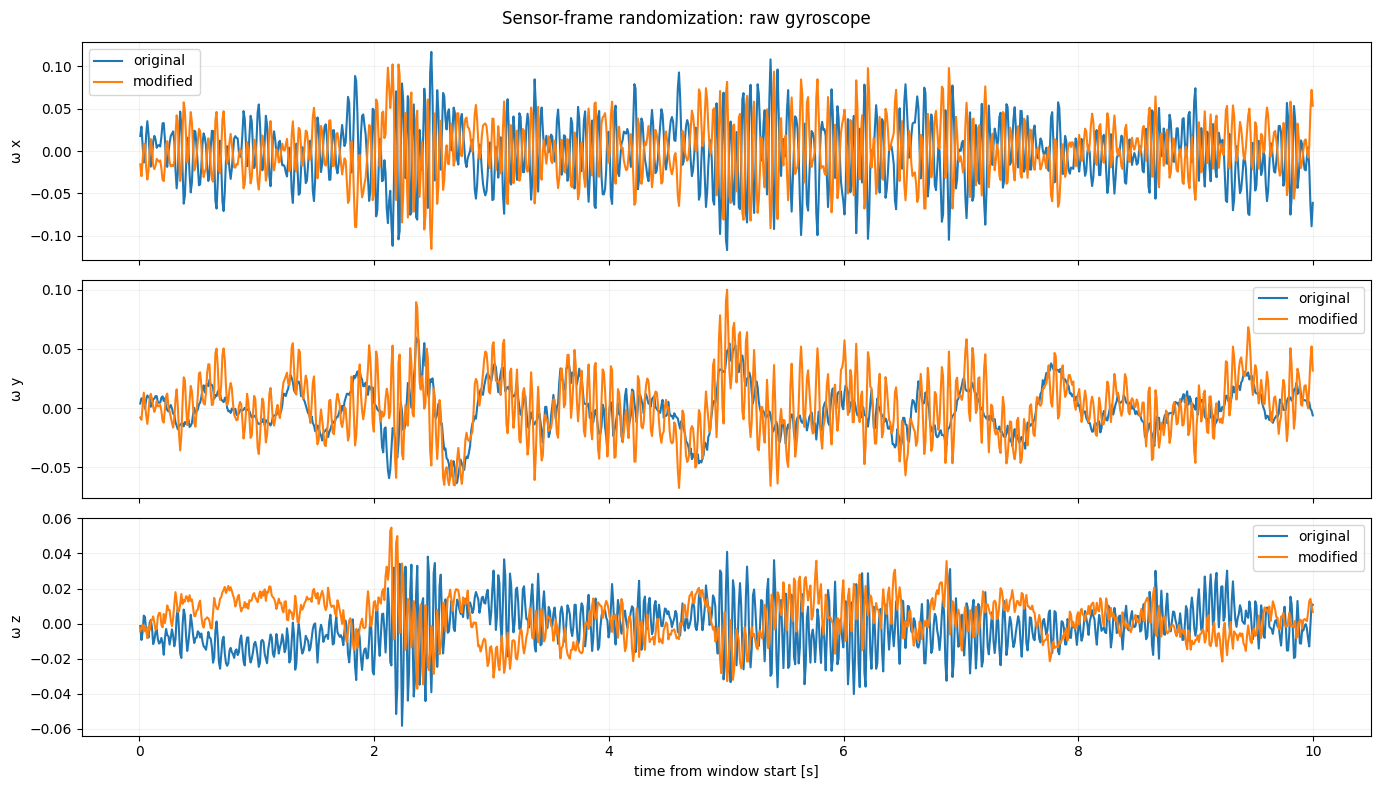

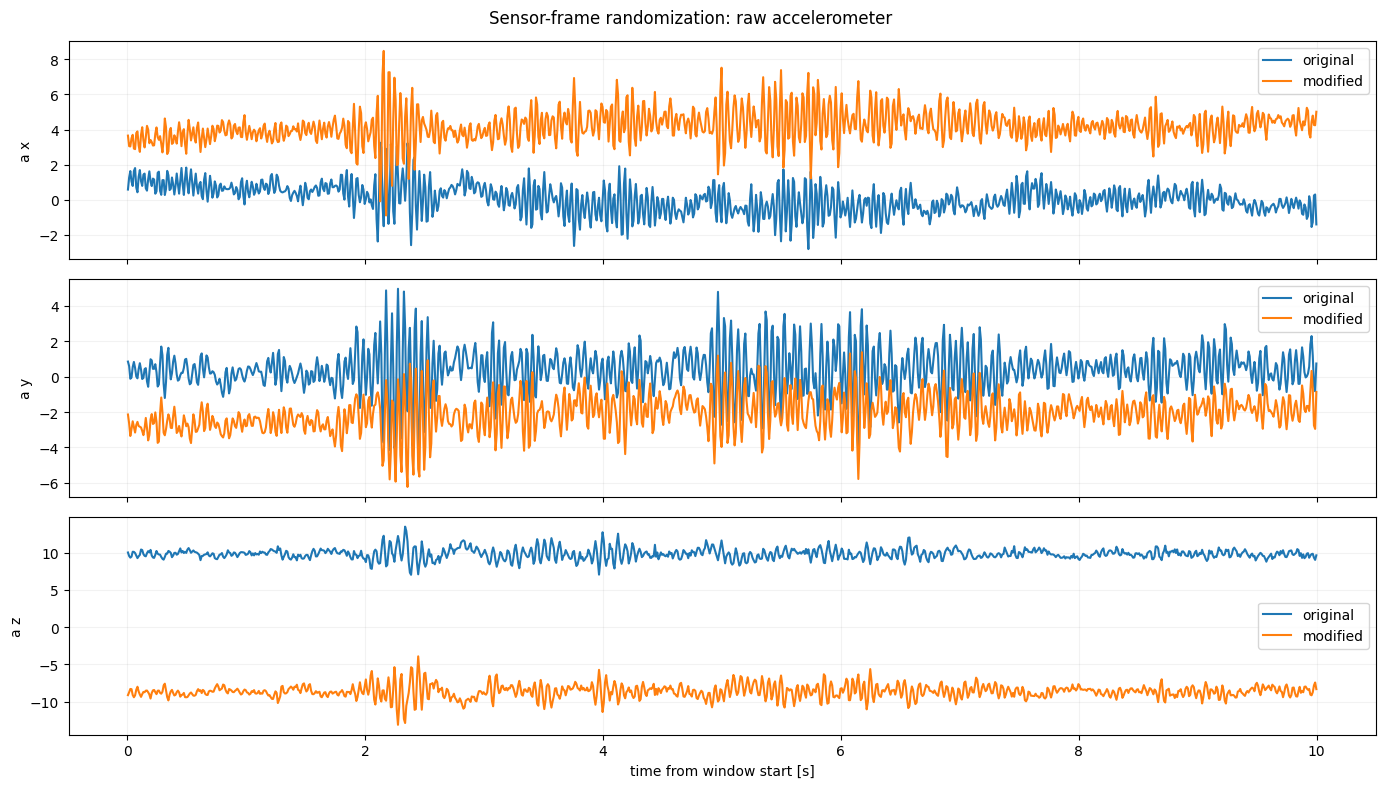

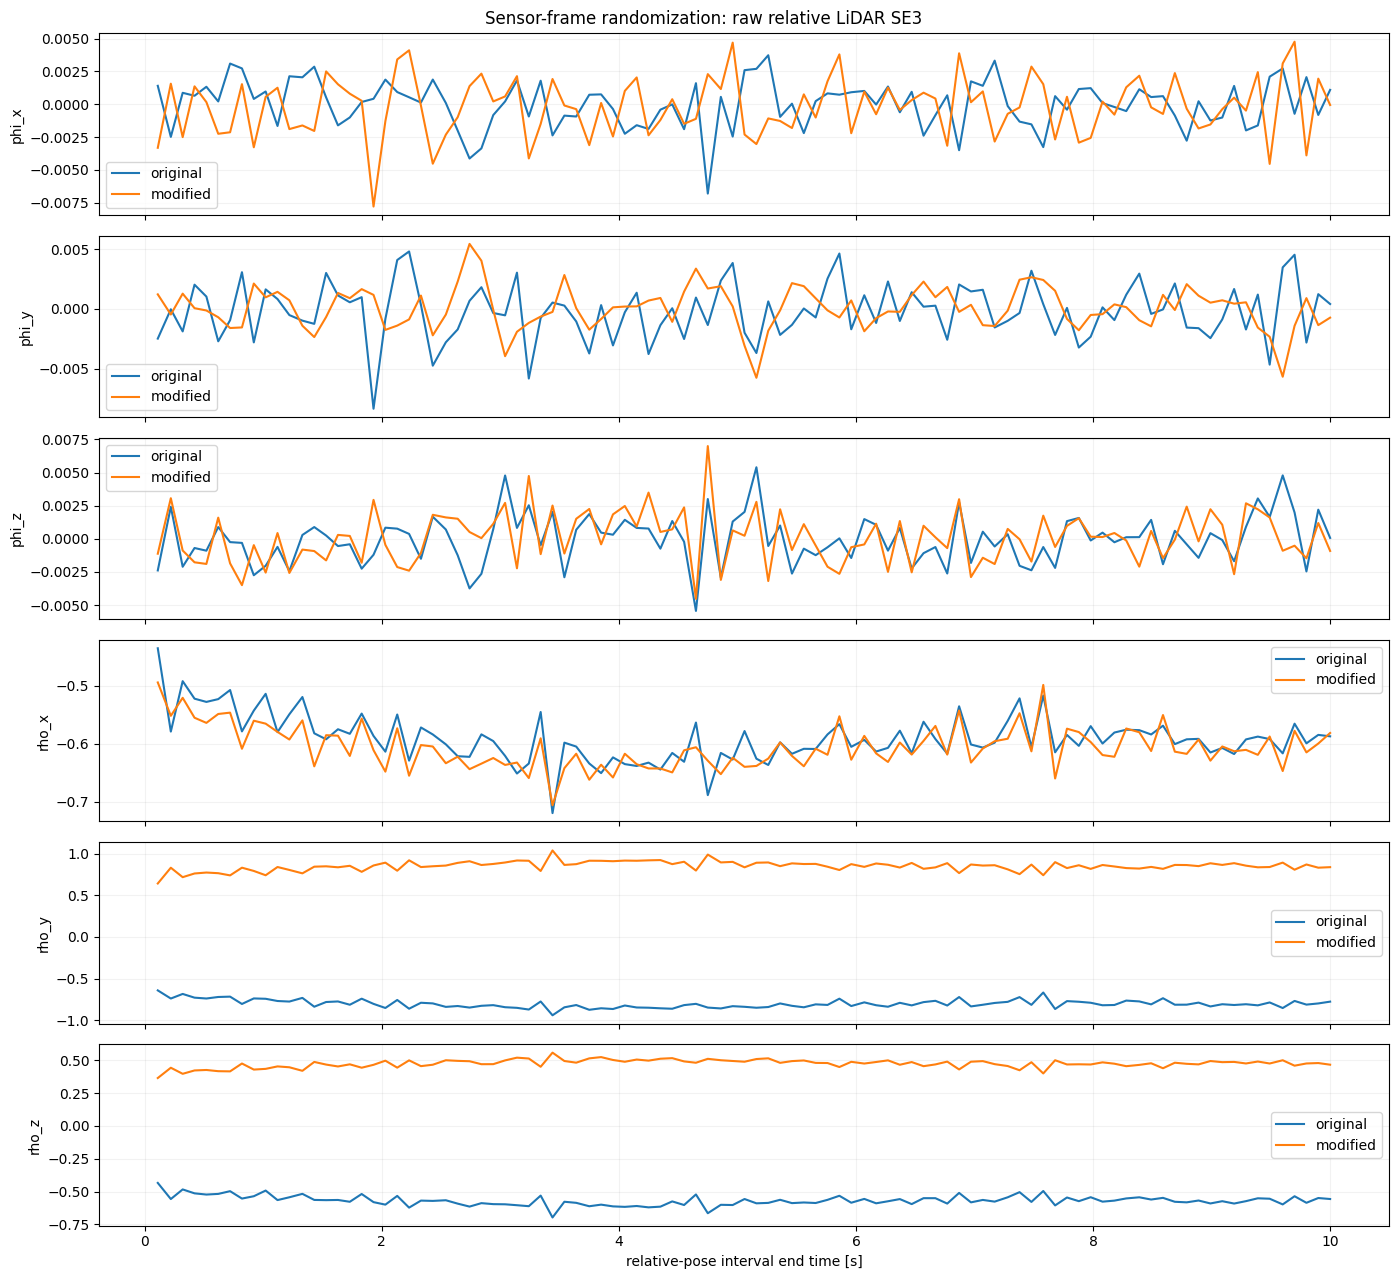


Maximum common-frame gyro difference: 4.163336342344337e-17
Maximum common-frame LiDAR matrix difference: 8.881784197001252e-16


In [40]:
frame_randomizer = SensorFrameRandomizer(
    FrameRandomizationConfig(
        enabled=True,
    )
)

frame_generator = torch.Generator().manual_seed(SEED)

frame_window, randomized_true_calibration, frame_randomization_by_key = frame_randomizer(base_window, generator=frame_generator)

print("Random frame transforms:")
for calibration_key, A in frame_randomization_by_key.items():
    print()
    print(calibration_key)
    print(A[0].detach().cpu().numpy())

plot_vector_comparison(base_window, frame_window, "gyro", "Sensor-frame randomization: raw gyroscope", "ω")
plot_vector_comparison(base_window, frame_window, "accel", "Sensor-frame randomization: raw accelerometer", "a")
plot_se3_comparison(base_window, frame_window, "lidar", "Sensor-frame randomization: raw relative LiDAR SE3")

##################################################
# Verify common-frame invariance for the gyro
##################################################

original_gyro = base_window.streams["gyro"]
randomized_gyro = frame_window.streams["gyro"]

original_gyro_mask = original_gyro.sample_mask[0]
randomized_gyro_mask = randomized_gyro.sample_mask[0]

gyro_world_original = canonicalize_vector(original_gyro.values[0, original_gyro_mask], base_window.current_calibration["imu"].transform[0])
gyro_world_randomized = canonicalize_vector(randomized_gyro.values[0, randomized_gyro_mask], randomized_true_calibration["imu"].transform[0])

print()
print("Maximum common-frame gyro difference:", torch.max(torch.abs(gyro_world_original - gyro_world_randomized)).item())

##################################################
# Verify common-frame invariance for relative LiDAR
##################################################

original_lidar = base_window.streams["lidar"]
randomized_lidar = frame_window.streams["lidar"]

original_lidar_mask = original_lidar.sample_mask[0]
randomized_lidar_mask = randomized_lidar.sample_mask[0]

lidar_world_original = canonicalize_relative_se3(original_lidar.values[0, original_lidar_mask], base_window.current_calibration["lidar"].transform[0])
lidar_world_randomized = canonicalize_relative_se3(randomized_lidar.values[0, randomized_lidar_mask], randomized_true_calibration["lidar"].transform[0])

print("Maximum common-frame LiDAR matrix difference:", torch.max(torch.abs(lidar_world_original - lidar_world_randomized)).item())

# current-prior perturbation


imu: true current state
  xi  = [ 0.    0.    0.    0.07  0.   -1.7 ]
  tau = 0.0
imu: perturbed model prior
  xi  = [-0.08379741  0.13230857 -0.11464688 -0.19337286  0.04968363 -1.70189894]
  tau = 0.008310743989480562
  sampled prior delta_xi = [-0.08379741  0.13230857 -0.11464688 -0.14936982  0.12283853 -0.00080114]
  sampled prior delta_tau = [0.00831074]

lidar: true current state
  xi  = [-0.90803649  0.39962779  2.22131177 -0.54393174 -0.0205385   1.94245725]
  tau = 0.0
lidar: perturbed model prior
  xi  = [-0.92383687  0.33513479  2.2092817  -0.44295008  0.16008002  1.91192613]
  tau = 0.02693365927211588
  sampled prior delta_xi = [ 0.04109058 -0.03281922  0.00623978 -0.0687204   0.15714737 -0.10102385]
  sampled prior delta_tau = [0.02693366]


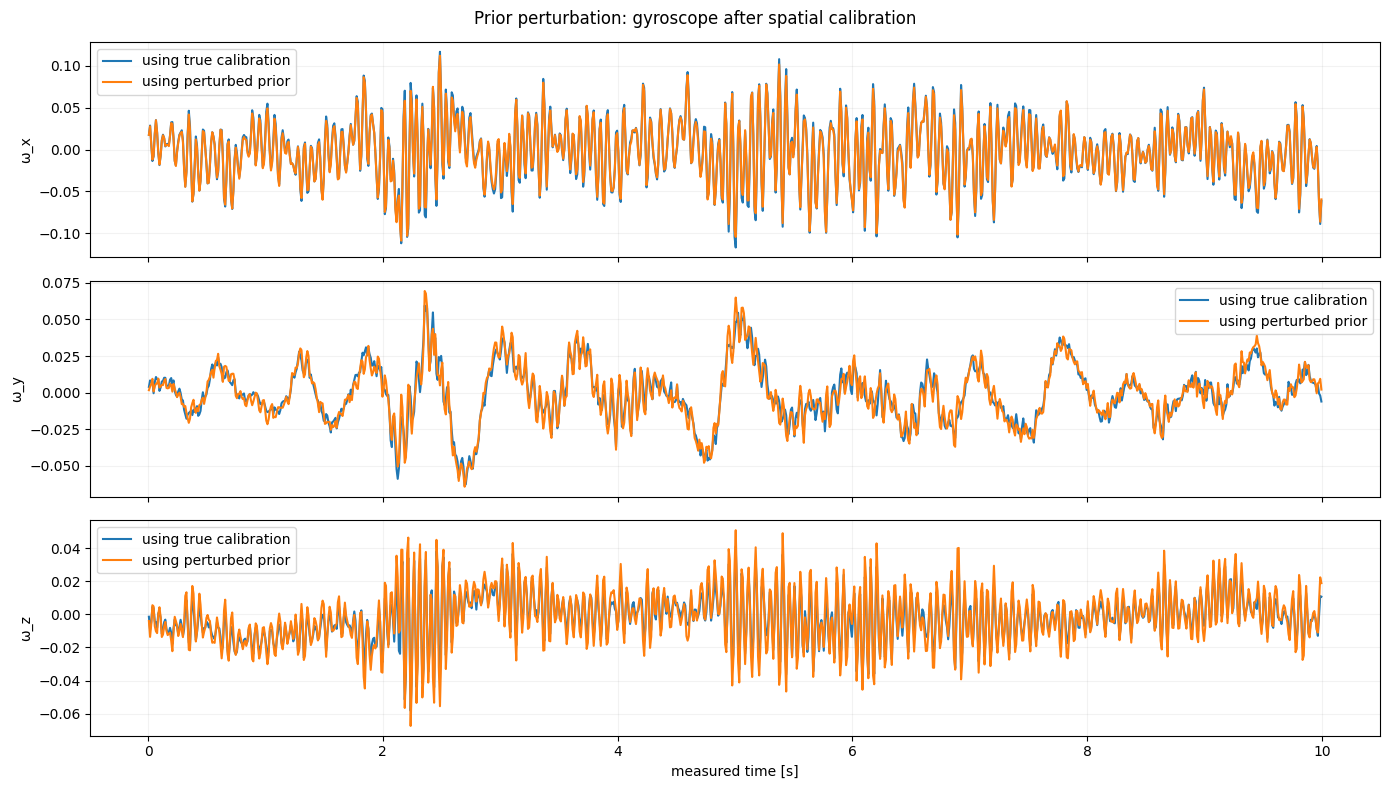

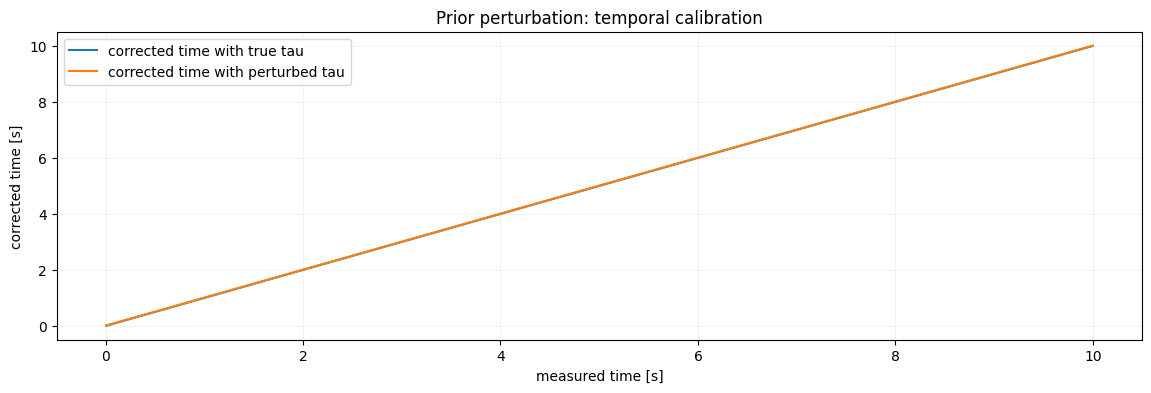

In [41]:
prior_perturber = CalibrationPriorPerturber(
    PriorPerturbationConfig(
        enabled=True,
        probability=1.0,
        rotation=PerturbationMagnitudeConfig(maximum=np.deg2rad(60.0)),
        translation=PerturbationMagnitudeConfig(maximum=0.20),
        time_offset=PerturbationMagnitudeConfig(maximum=0.03),
    )
)

prior_generator = torch.Generator().manual_seed(SEED)

perturbed_prior, prior_delta_xi, prior_delta_tau = prior_perturber(base_window.current_calibration, generator=prior_generator)

for calibration_key in base_window.current_calibration:
    print()
    print_calibration_state(f"{calibration_key}: true current state", base_window.current_calibration[calibration_key])
    print_calibration_state(f"{calibration_key}: perturbed model prior", perturbed_prior[calibration_key])

    if calibration_key in prior_delta_xi:
        print("  sampled prior delta_xi =", prior_delta_xi[calibration_key][0].detach().cpu().numpy())

    if calibration_key in prior_delta_tau:
        print("  sampled prior delta_tau =", prior_delta_tau[calibration_key][0].detach().cpu().numpy())

##################################################
# Gyroscope as seen after calibration normalization
##################################################

gyro_stream = base_window.streams["gyro"]
gyro_mask = gyro_stream.sample_mask[0]
gyro_t = gyro_stream.timestamps[0, gyro_mask].detach().cpu().numpy()
gyro_raw = gyro_stream.values[0, gyro_mask]

gyro_true_world = canonicalize_vector(gyro_raw, base_window.current_calibration["imu"].transform[0]).detach().cpu().numpy()
gyro_prior_world = canonicalize_vector(gyro_raw, perturbed_prior["imu"].transform[0]).detach().cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for axis_index, axis_name in enumerate(AXIS_NAMES):
    axes[axis_index].plot(gyro_t, gyro_true_world[:, axis_index], label="using true calibration")
    axes[axis_index].plot(gyro_t, gyro_prior_world[:, axis_index], label="using perturbed prior")
    axes[axis_index].set_ylabel(f"ω_{axis_name}")
    axes[axis_index].grid(True)
    axes[axis_index].legend()

axes[-1].set_xlabel("measured time [s]")
fig.suptitle("Prior perturbation: gyroscope after spatial calibration")
fig.tight_layout()
plt.show()

##################################################
# Temporal prior difference
##################################################

true_tau = float(base_window.current_calibration["imu"].time_offset[0, 0])
prior_tau = float(perturbed_prior["imu"].time_offset[0, 0])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(gyro_t, gyro_t + true_tau, label="corrected time with true tau")
ax.plot(gyro_t, gyro_t + prior_tau, label="corrected time with perturbed tau")
ax.set_xlabel("measured time [s]")
ax.set_ylabel("corrected time [s]")
ax.set_title("Prior perturbation: temporal calibration")
ax.grid(True)
ax.legend()
plt.show()

# true calibration-event augmentation


imu
  occurred = True
  profile = TransitionProfile.SMOOTHSTEP
  change time [s] = 6.263477251637234
  duration [s] = 2.0
  delta_xi = [ 0.64059877 -0.13488532 -0.11332187  0.00548651  0.00247375 -0.01437963]
  delta_tau = [-0.00973603]

lidar
  occurred = True
  profile = TransitionProfile.SMOOTHSTEP
  change time [s] = 3.053615792340309
  duration [s] = 2.0
  delta_xi = [-0.02508002  0.28218935 -0.0801381   0.01134978  0.17280985 -0.08501161]
  delta_tau = [0.00469517]


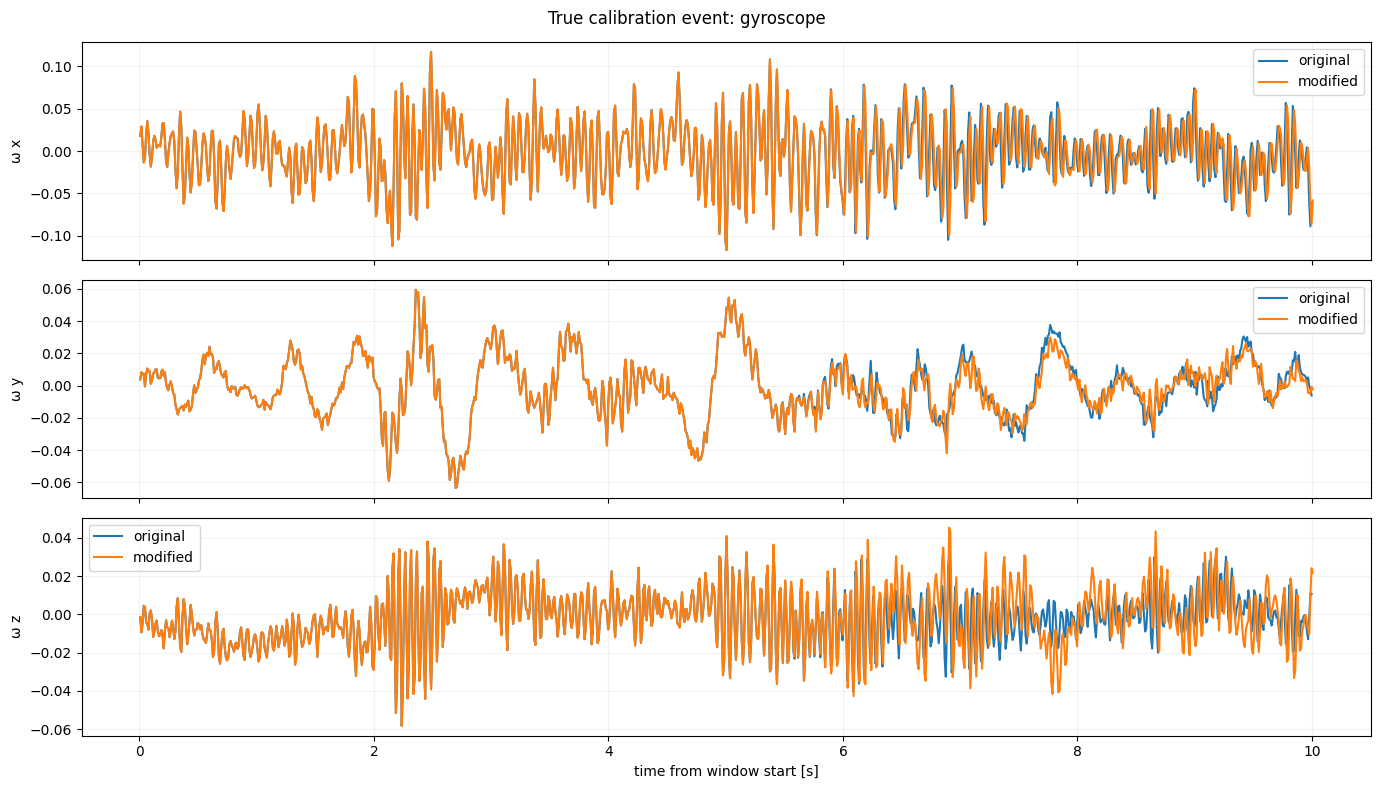

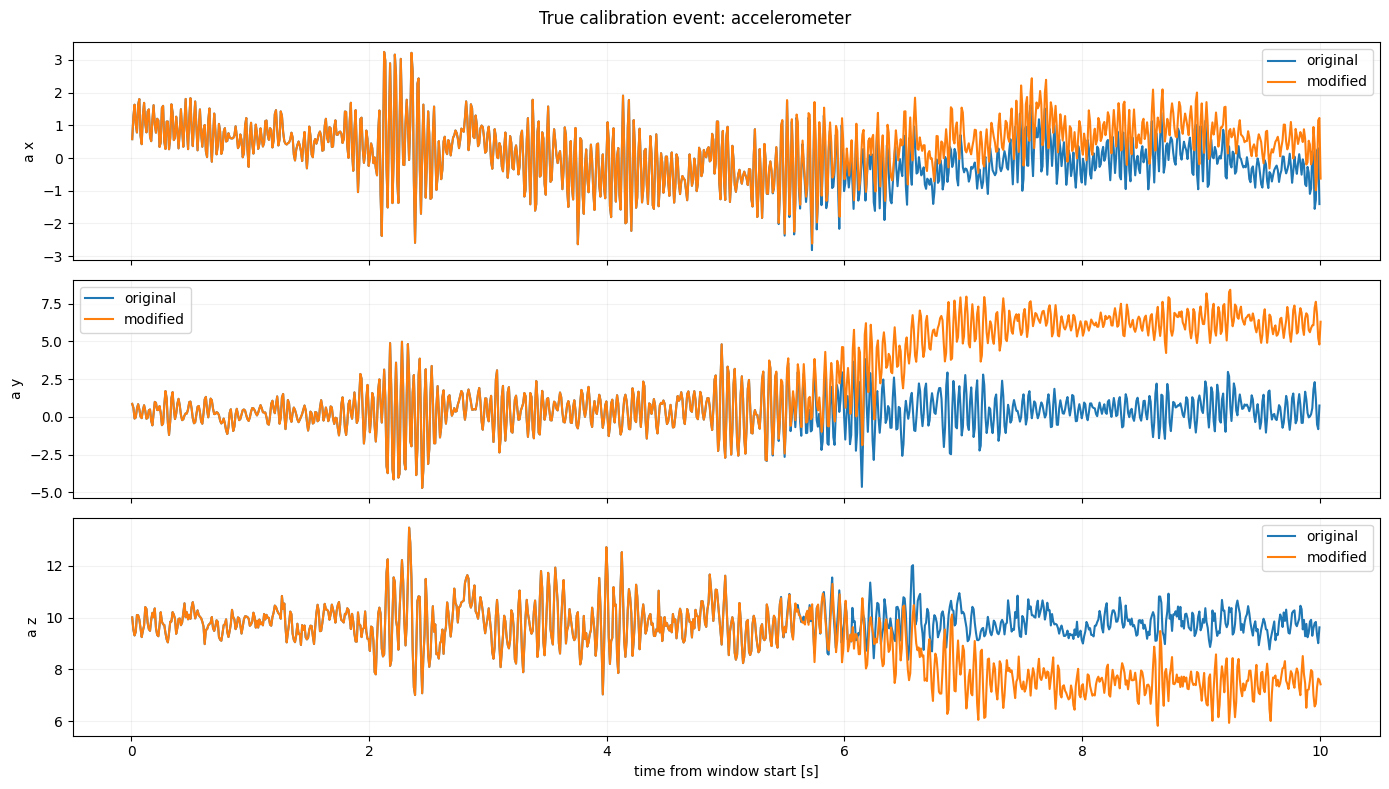

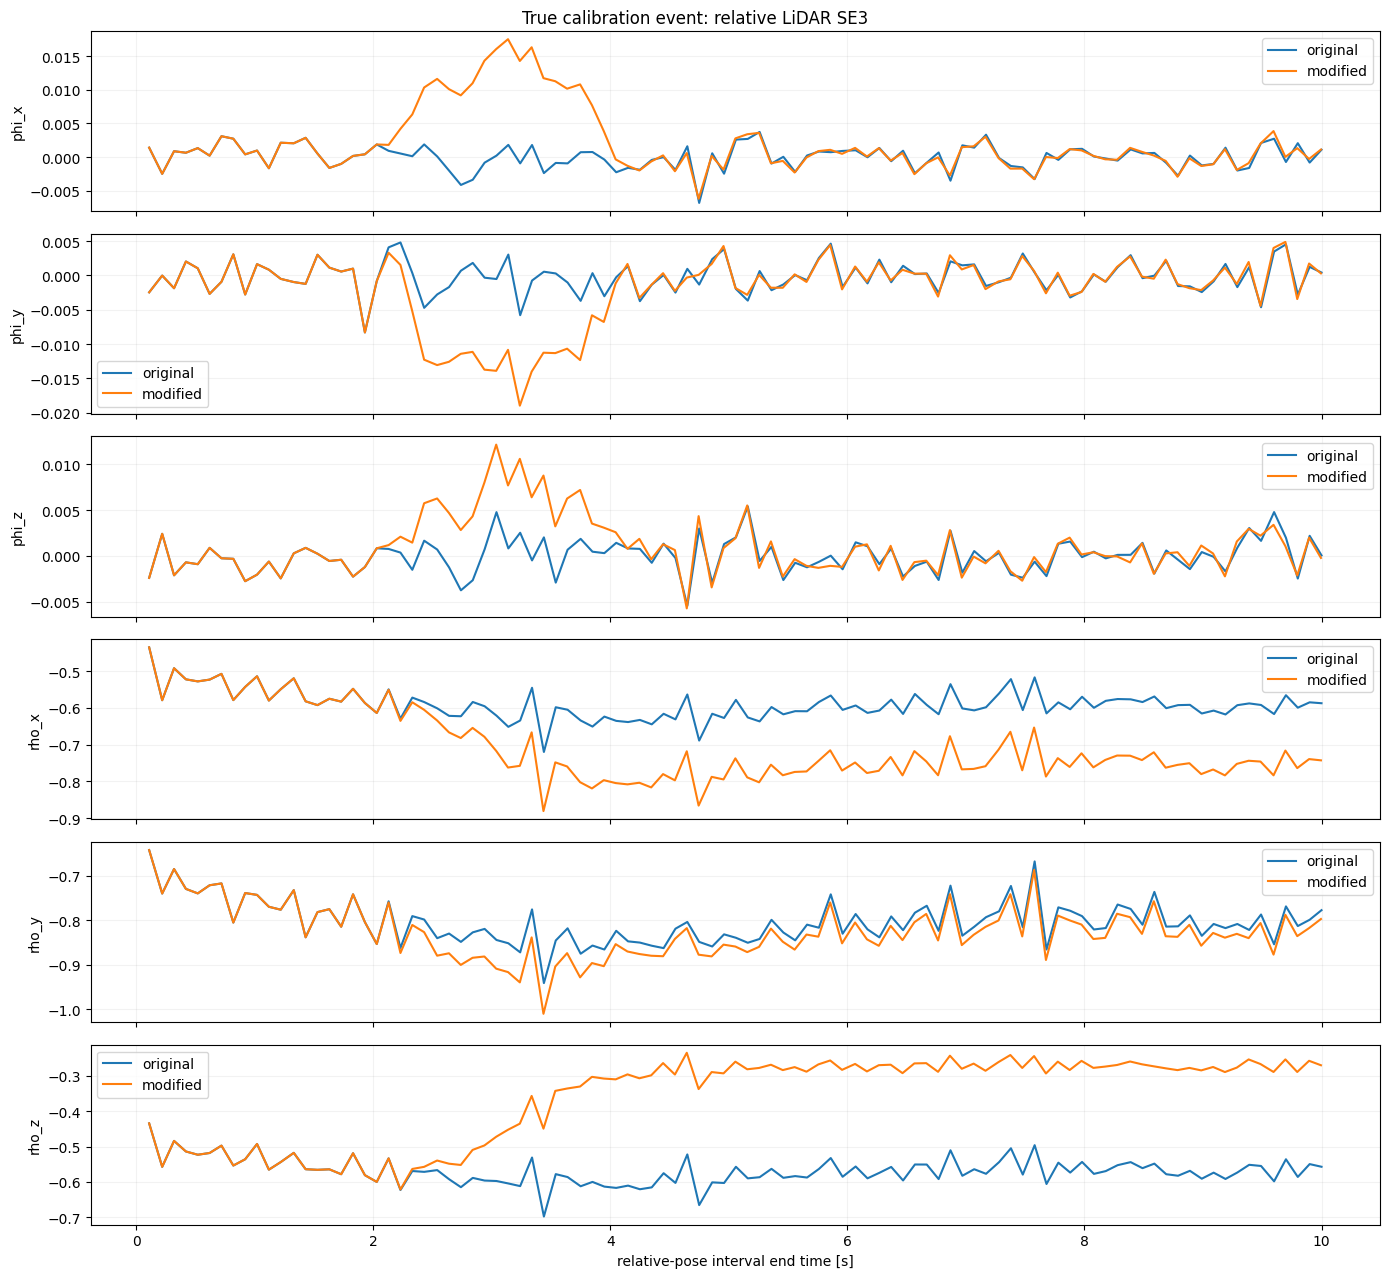

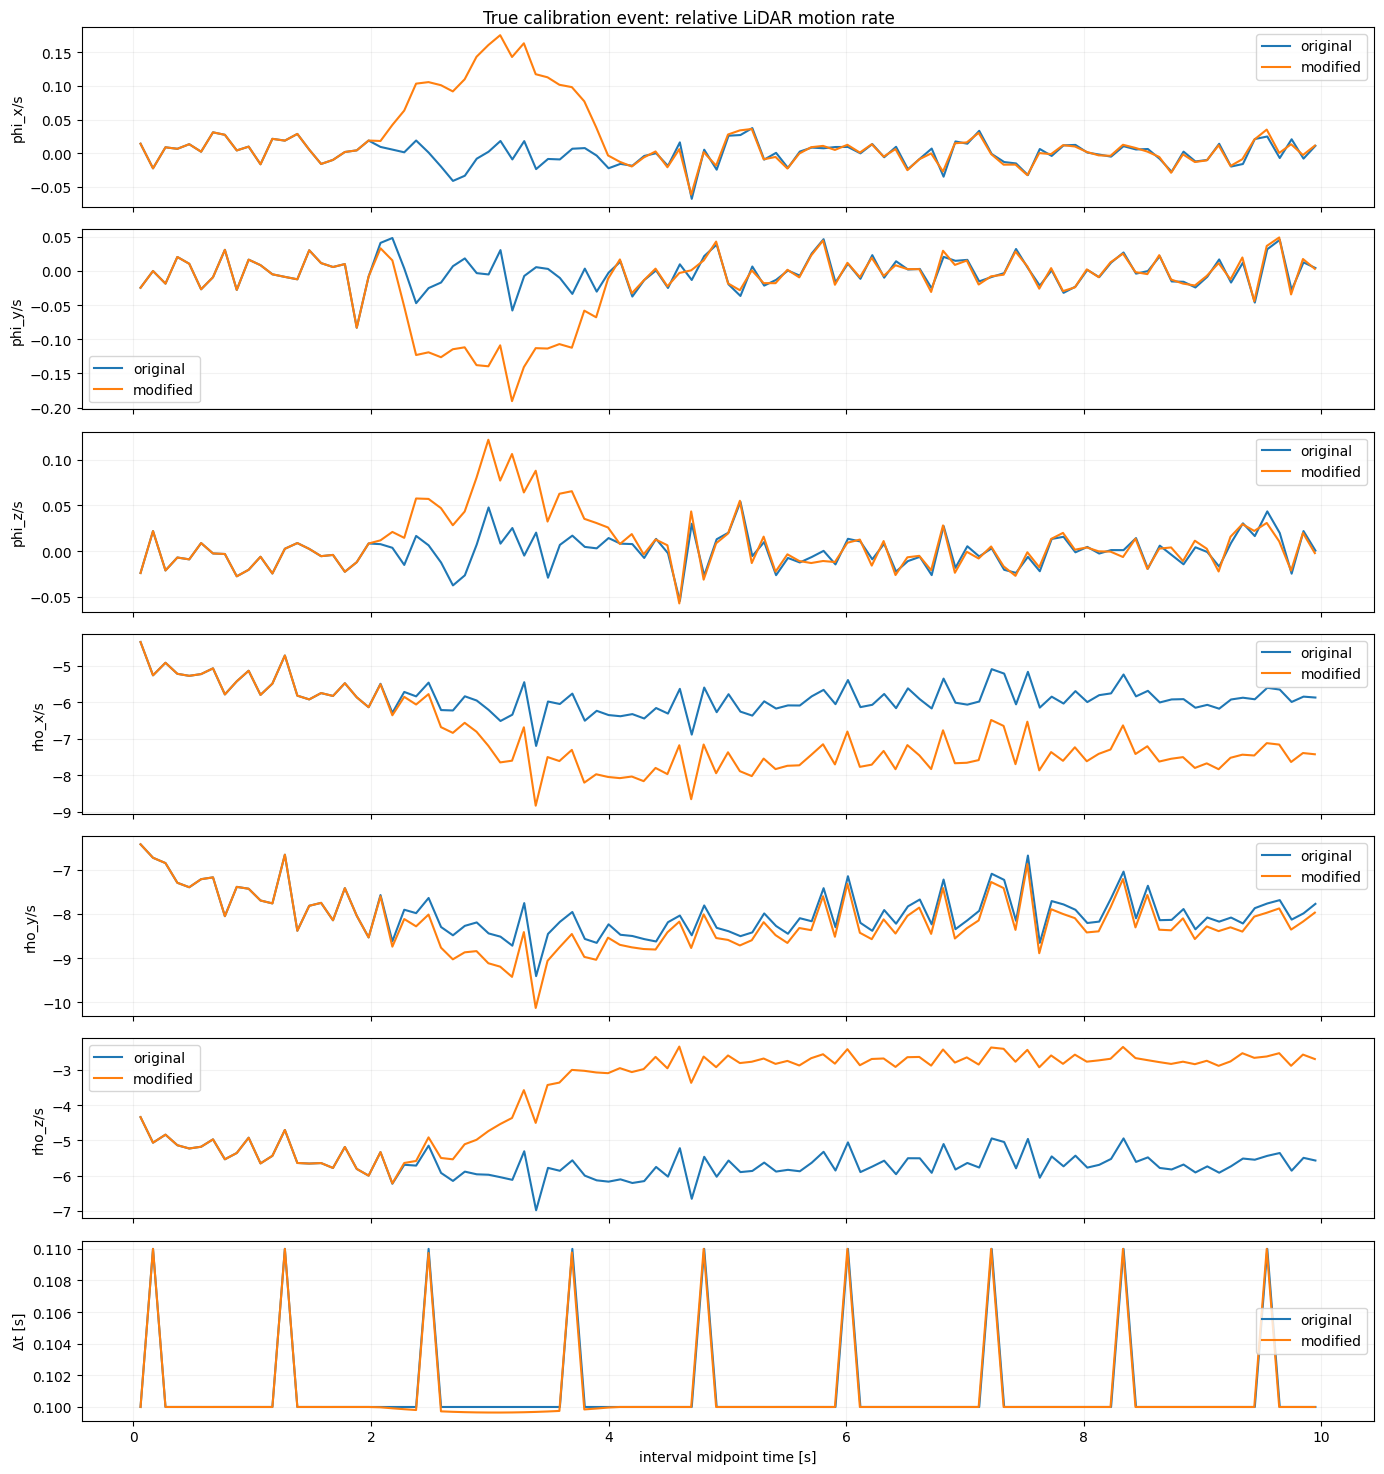

In [47]:
event_sampler = CalibrationEventSampler(
    CalibrationEventConfig(
        enabled=True,
        event_probability=1.0,
        rotation_probability=1.0,
        translation_probability=1.0,
        time_offset_probability=1.0,
        rotation=PerturbationMagnitudeConfig(maximum=np.deg2rad(60.0)),
        translation=PerturbationMagnitudeConfig(maximum=0.20),
        time_offset=PerturbationMagnitudeConfig(maximum=0.03),
        profile_weights={
            TransitionProfile.SMOOTHSTEP: 1.0,
        },
        minimum_transition_duration_s=2.0,
        maximum_transition_duration_s=2.0,
        minimum_pre_event_fraction=0.2,
        minimum_post_event_fraction=0.2,
    )
)

event_generator = torch.Generator().manual_seed(SEED)

events = event_sampler(base_window, base_window.current_calibration, generator=event_generator)

calibration_truth = {
    calibration_key: CalibrationTrajectory(
        pre_event=state,
        event=events[calibration_key],
    )
    for calibration_key, state in base_window.current_calibration.items()
}

event_renderer = CalibrationEventRenderer()
event_window = event_renderer(base_window, calibration_truth)

for calibration_key, event in events.items():
    print()
    print(calibration_key)
    print("  occurred =", bool(event.occurred[0, 0]))
    print("  profile =", event.profiles[0])
    print("  change time [s] =", float(event.change_time_s[0, 0]))
    print("  duration [s] =", float(event.transition_duration_s[0, 0]))
    print("  delta_xi =", event.delta_xi[0].detach().cpu().numpy())
    print("  delta_tau =", event.delta_tau[0].detach().cpu().numpy())

plot_vector_comparison(base_window, event_window, "gyro", "True calibration event: gyroscope", "ω")
plot_vector_comparison(base_window, event_window, "accel", "True calibration event: accelerometer", "a")
plot_se3_comparison(base_window, event_window, "lidar", "True calibration event: relative LiDAR SE3")
plot_relative_se3_rate_comparison(
    base_window,
    event_window,
    "lidar",
    "True calibration event: relative LiDAR motion rate",
)

# plot the sampled event profiles themselves

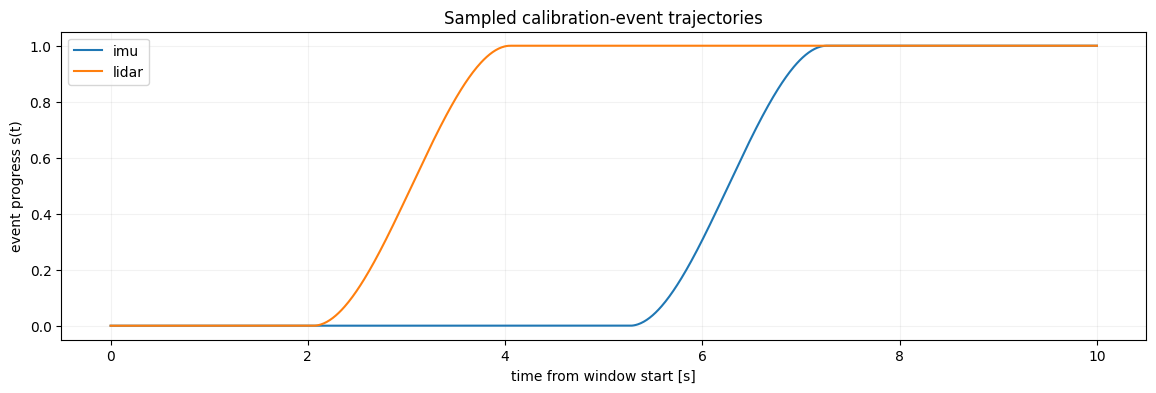

In [43]:
from obscalib.augmentations.profiles import evaluate_transition_profiles

profile_t = torch.linspace(0.0, WINDOW_DURATION_S, 1000, dtype=DTYPE).reshape(1, -1)

fig, ax = plt.subplots(figsize=(14, 4))

for calibration_key, event in events.items():
    progress = evaluate_transition_profiles(
        timestamps_s=profile_t,
        change_time_s=event.change_time_s,
        transition_duration_s=event.transition_duration_s,
        profiles=event.profiles,
    )

    ax.plot(profile_t[0].detach().cpu().numpy(), progress[0].detach().cpu().numpy(), label=calibration_key)

ax.set_xlabel("time from window start [s]")
ax.set_ylabel("event progress s(t)")
ax.set_title("Sampled calibration-event trajectories")
ax.set_ylim(-0.05, 1.05)
ax.grid(True)
ax.legend()
plt.show()

# measurement-noise augmentation

Sampled constant vector biases:
gyro [[-0.00037257 -0.00371513  0.00168846]]
accel [[-0.00962501 -0.01235693  0.03724814]]


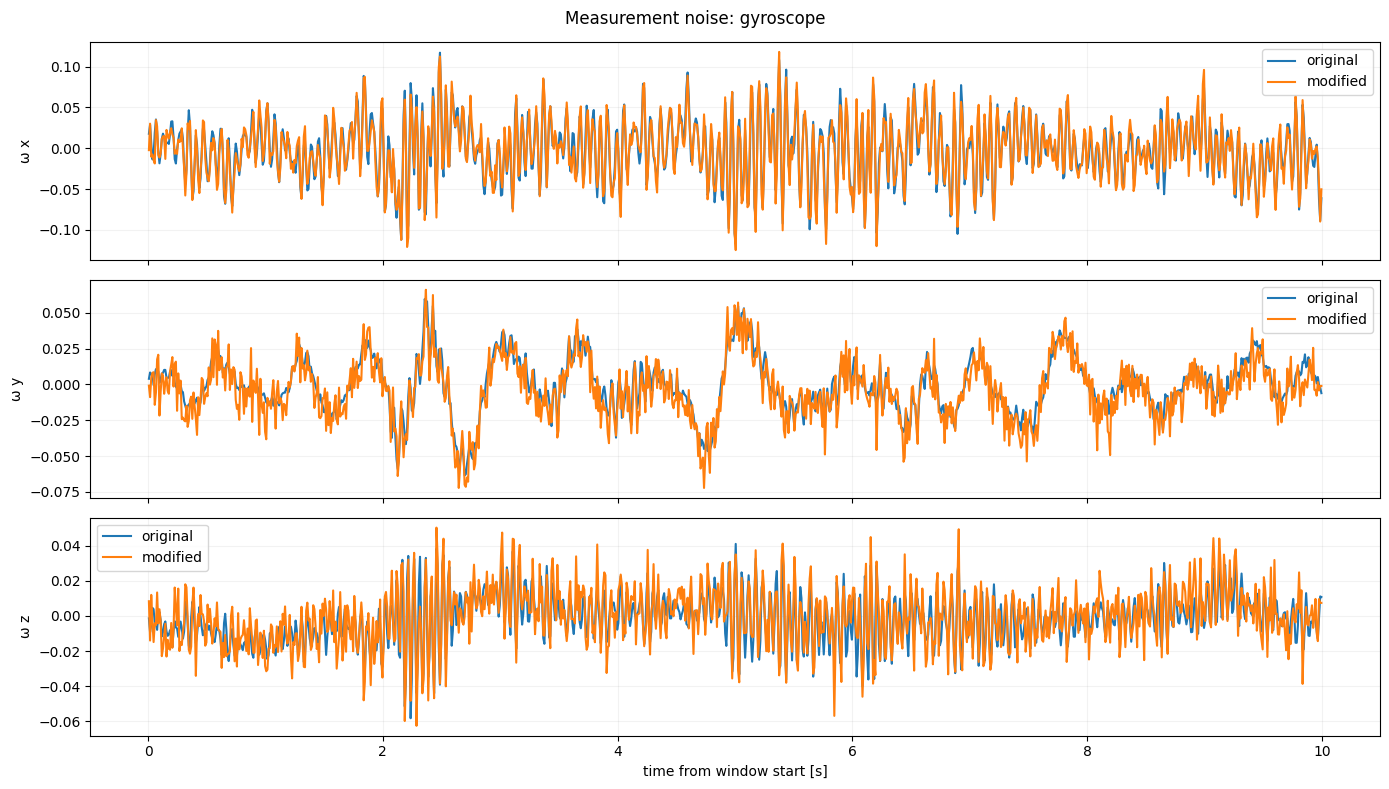

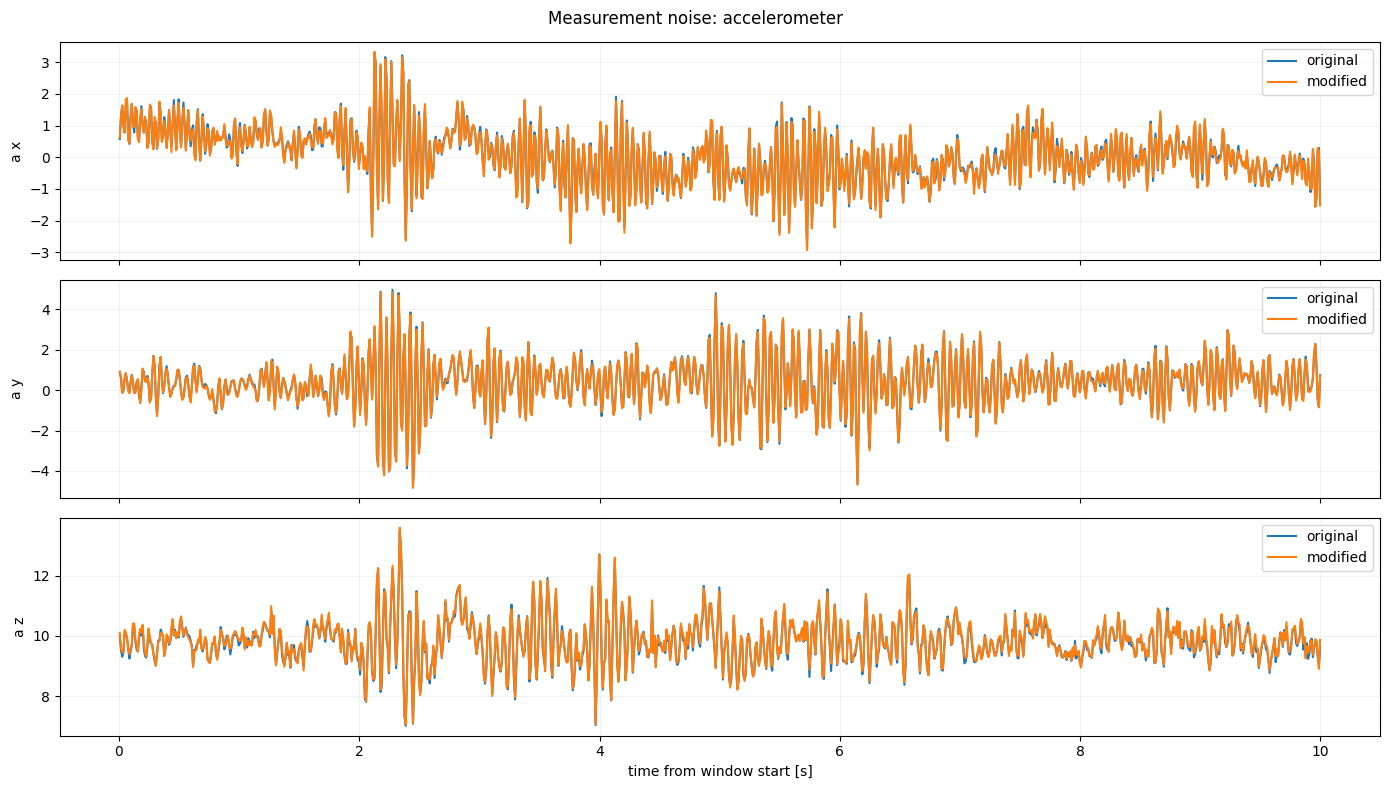

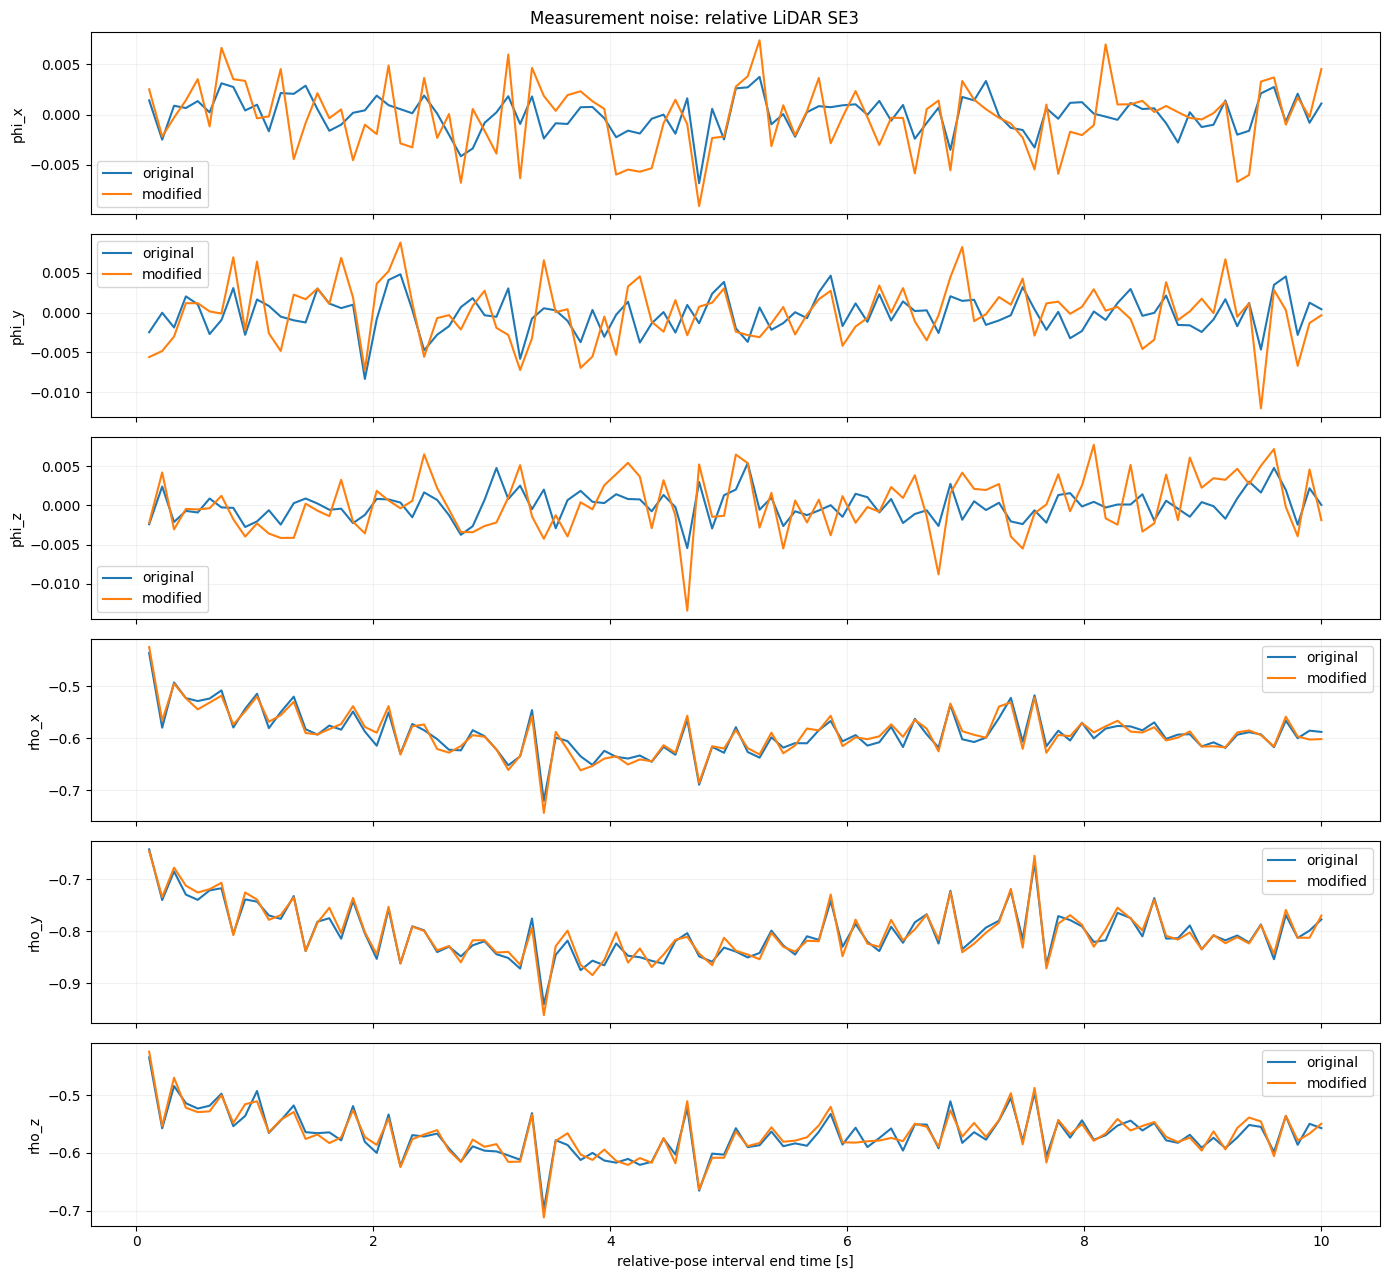

In [44]:
noise_augmenter = MeasurementNoiseAugmenter(
    NoiseAugmentationConfig(
        enabled=True,
        vector_by_type={
            MeasurementType.IMU_GYROSCOPE: VectorNoiseConfig(gaussian_std=0.01, window_bias_std=0.003),
            MeasurementType.IMU_ACCELEROMETER: VectorNoiseConfig(gaussian_std=0.08, window_bias_std=0.03),
        },
        se3_by_type={
            MeasurementType.LIDAR_POSE: SE3NoiseConfig(rotation_std=np.deg2rad(0.15), translation_std=0.01),
        },
    )
)

noise_generator = torch.Generator().manual_seed(SEED)

noise_window, noise_bias_by_stream = noise_augmenter(base_window, generator=noise_generator)

print("Sampled constant vector biases:")

for stream_key, bias in noise_bias_by_stream.items():
    print(stream_key, bias.detach().cpu().numpy())

plot_vector_comparison(base_window, noise_window, "gyro", "Measurement noise: gyroscope", "ω")
plot_vector_comparison(base_window, noise_window, "accel", "Measurement noise: accelerometer", "a")
plot_se3_comparison(base_window, noise_window, "lidar", "Measurement noise: relative LiDAR SE3")

# useful residual plots for noise

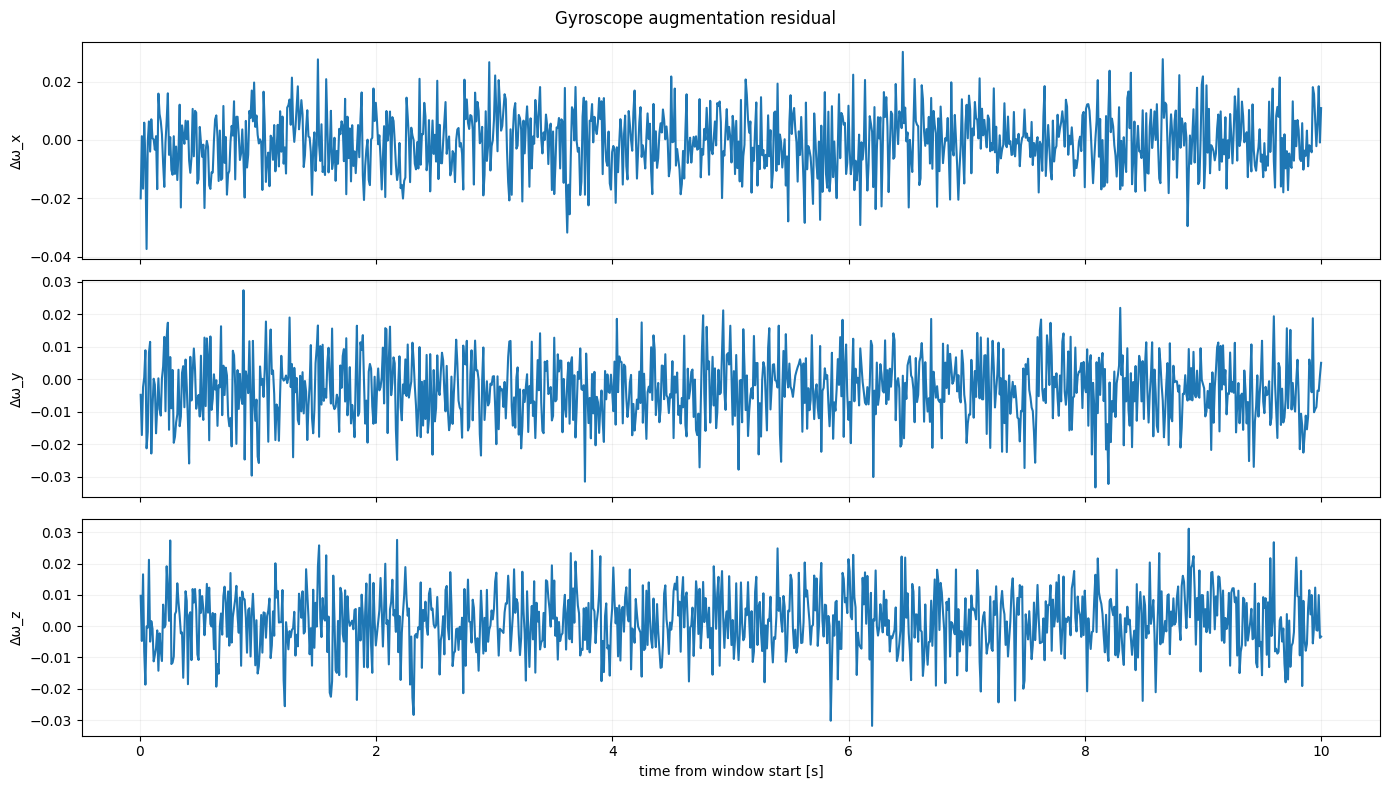

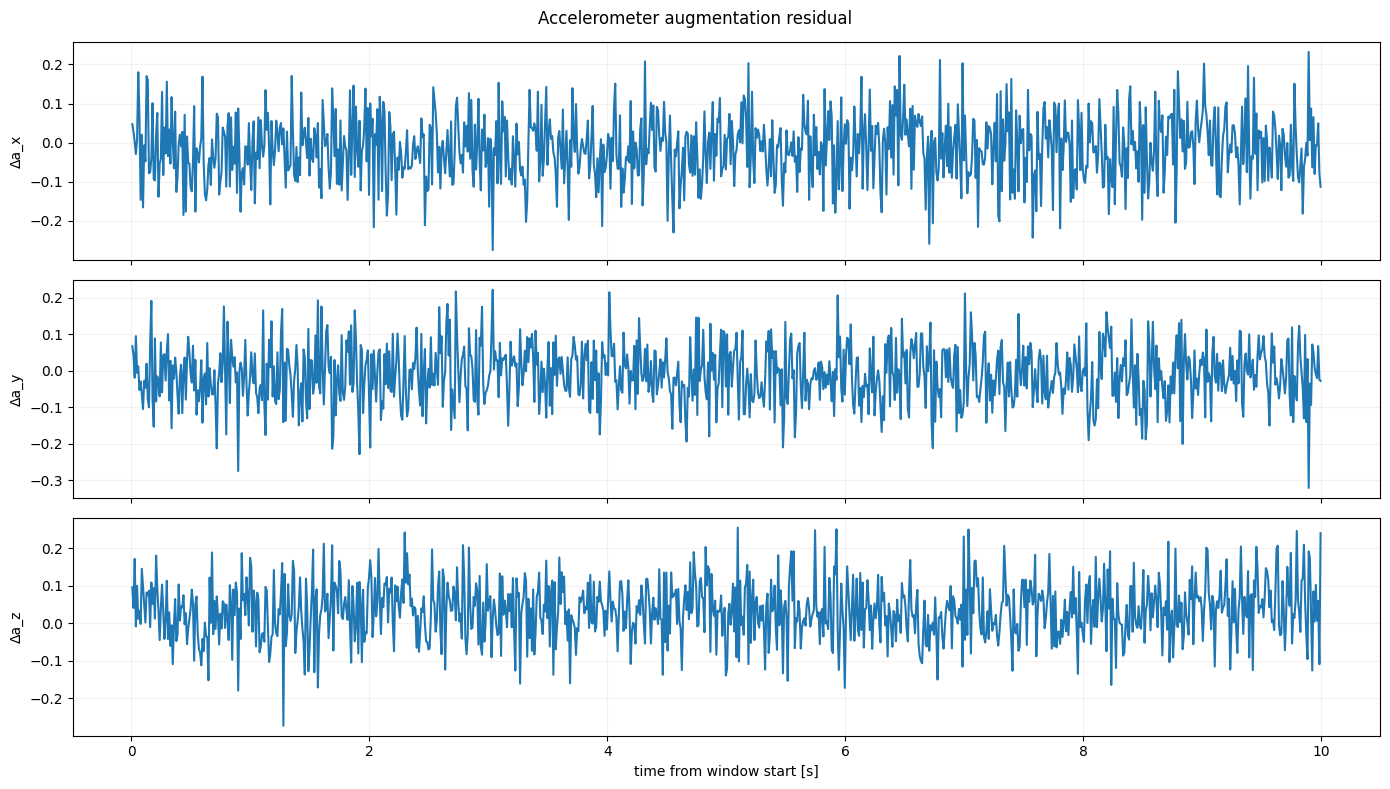

In [45]:
for stream_key, title, ylabel in (
    ("gyro", "Gyroscope augmentation residual", "Δω"),
    ("accel", "Accelerometer augmentation residual", "Δa"),
):
    original_t, original_values, _ = valid_stream_arrays(base_window, stream_key)
    noisy_t, noisy_values, _ = valid_stream_arrays(noise_window, stream_key)

    if not np.allclose(original_t, noisy_t):
        raise ValueError(f"Noise augmentation unexpectedly changed timestamps for {stream_key!r}.")

    residual = noisy_values - original_values

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for axis_index, axis_name in enumerate(AXIS_NAMES):
        axes[axis_index].plot(original_t, residual[:, axis_index])
        axes[axis_index].set_ylabel(f"{ylabel}_{axis_name}")
        axes[axis_index].grid(True)

    axes[-1].set_xlabel("time from window start [s]")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

# optional full-pipeline sanity check

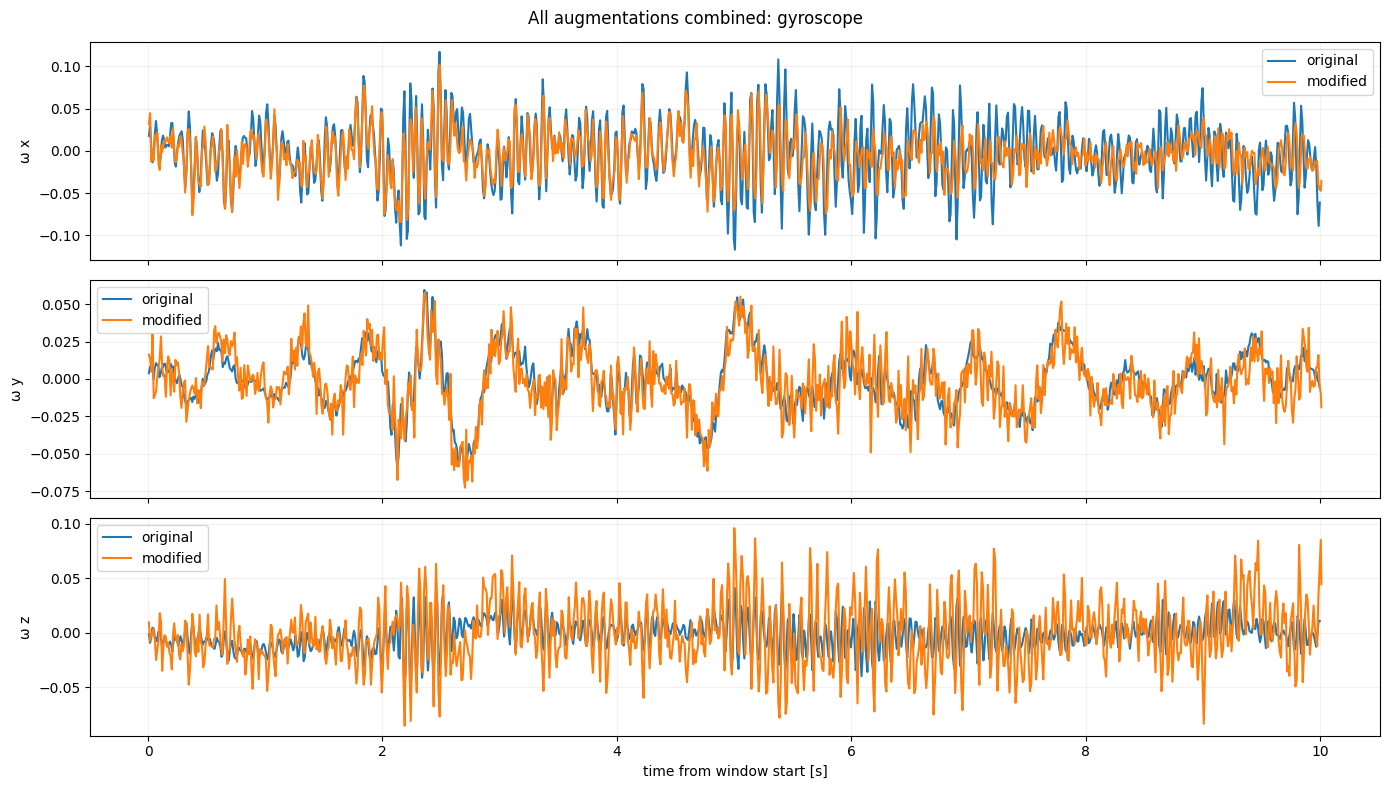

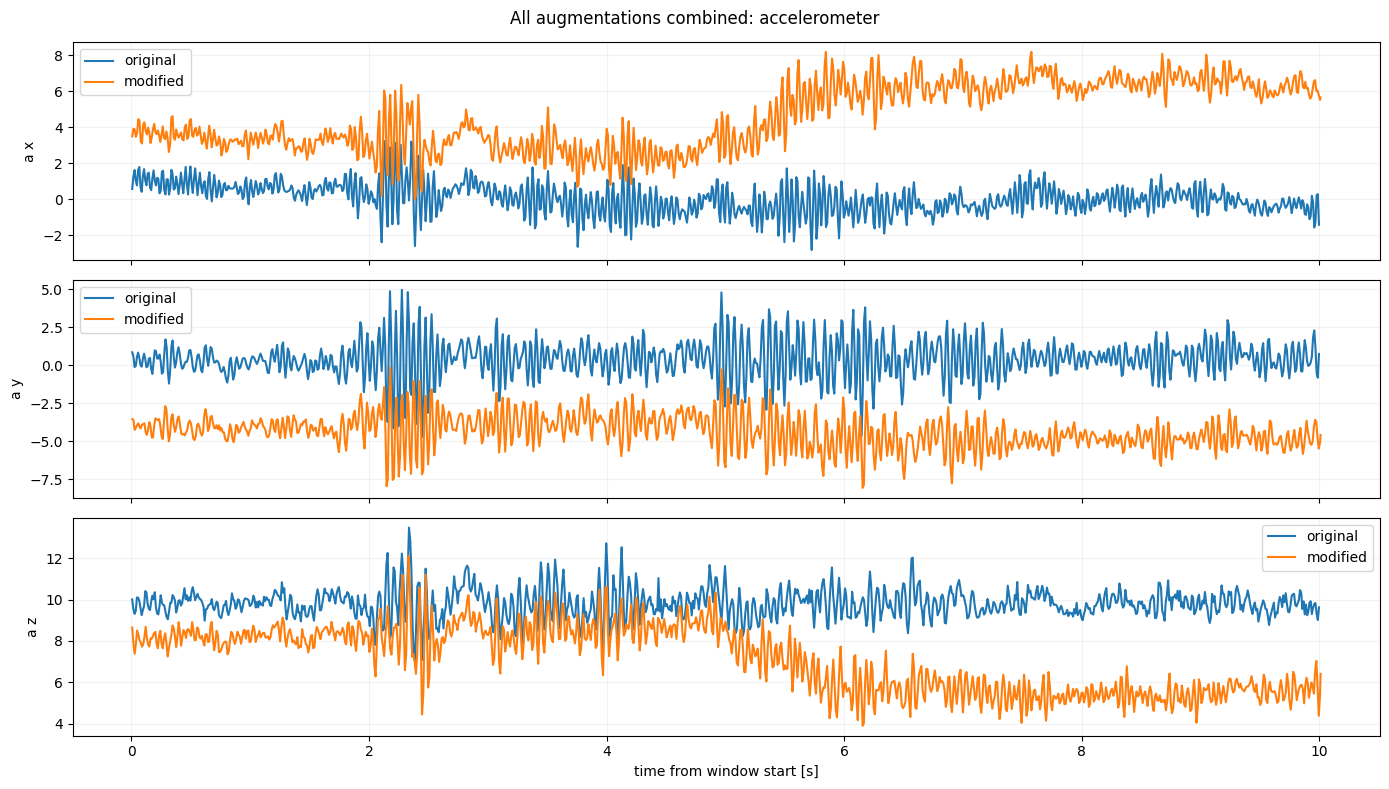

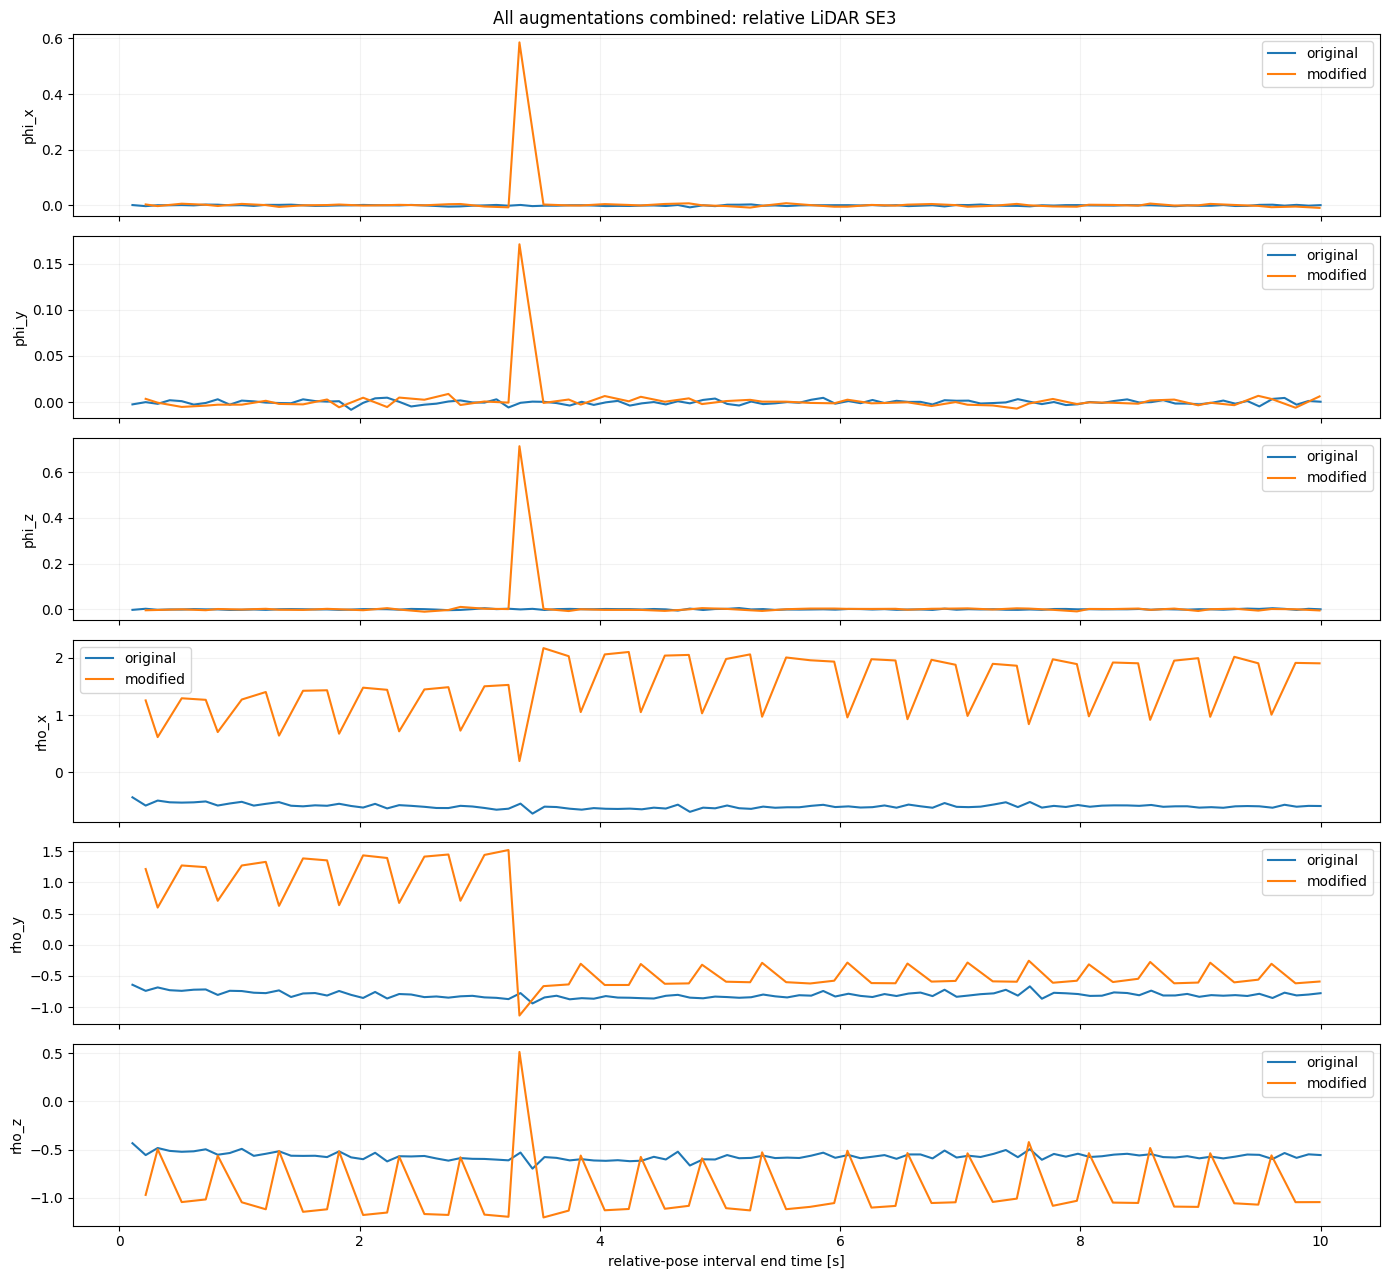

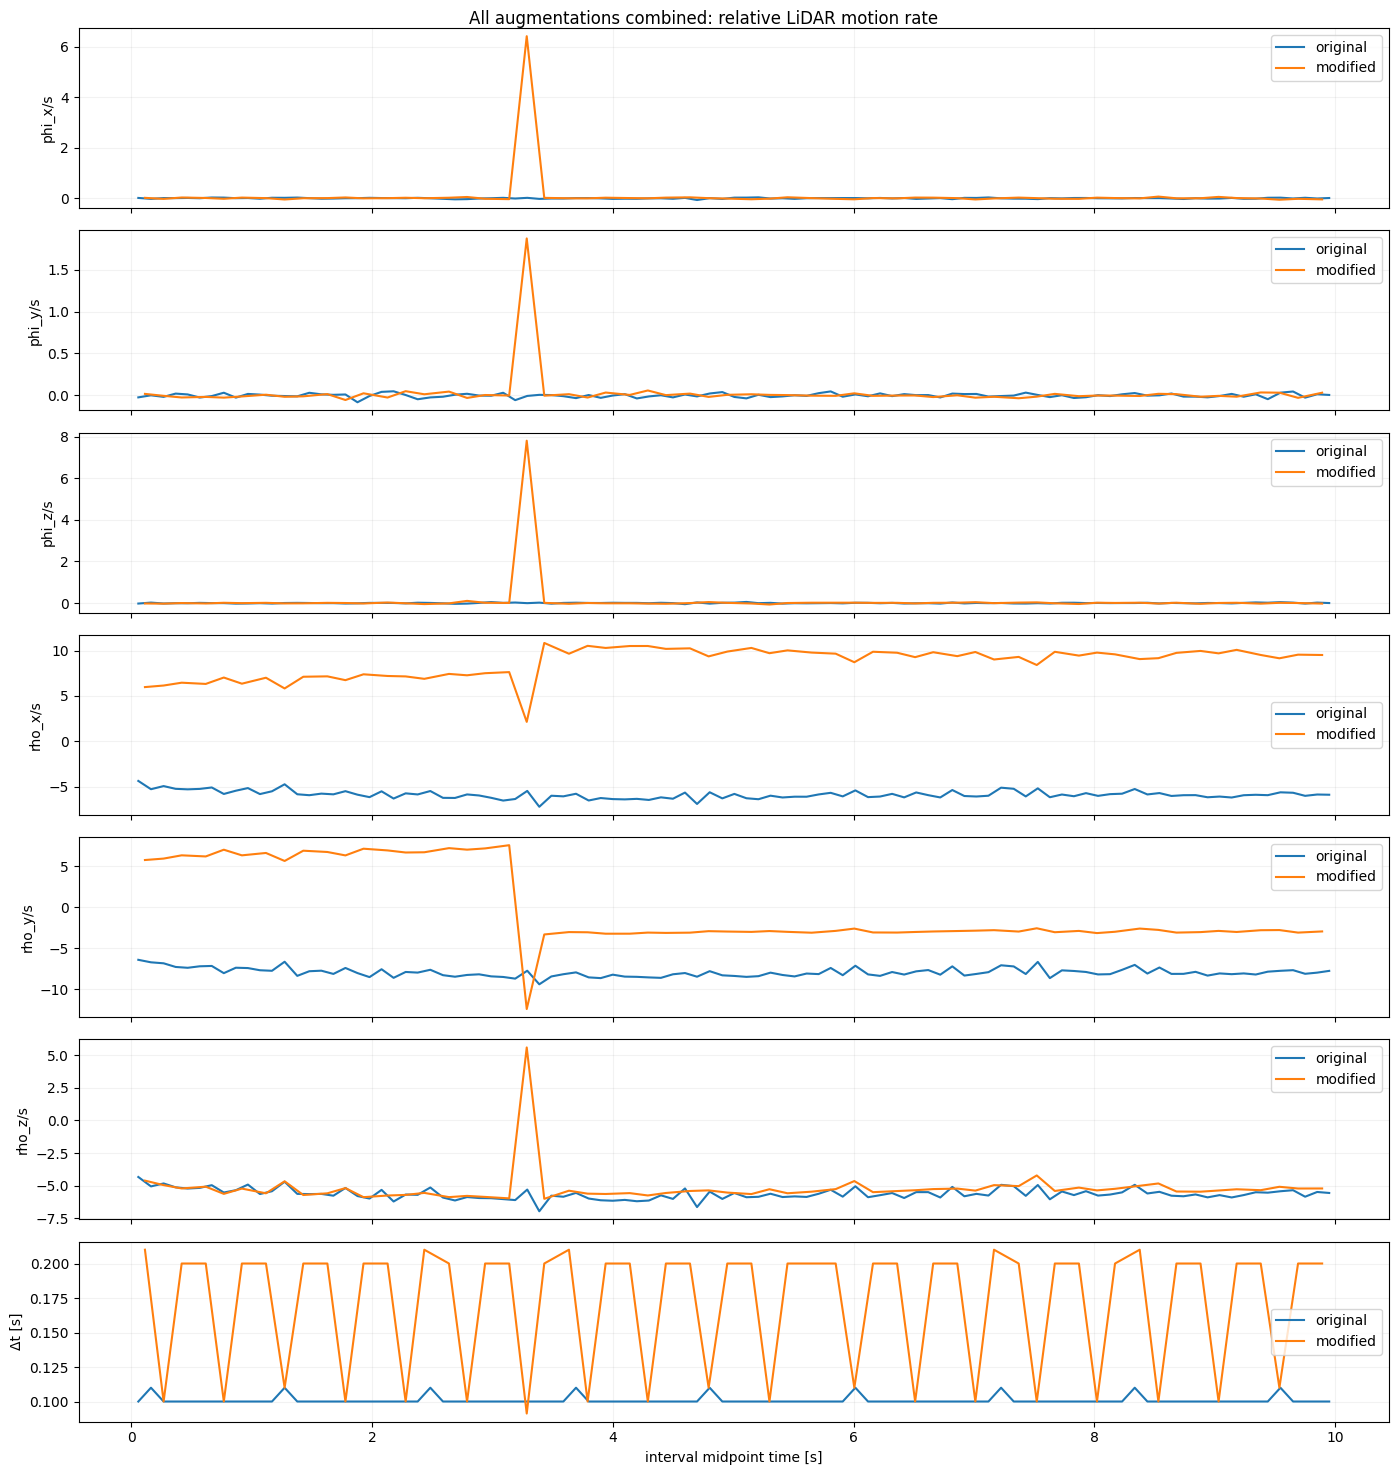

Augmentation record:
AugmentationRecord(calibration_keys=('imu', 'lidar'), frame_randomization_by_key={'lidar': tensor([[[-0.3509, -0.8332, -0.4274,  0.0000],
         [ 0.0303, -0.4663,  0.8841,  0.0000],
         [-0.9359,  0.2973,  0.1888,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], dtype=torch.float64), 'imu': tensor([[[ 0.9098, -0.1773, -0.3752,  0.0000],
         [ 0.3136,  0.8860,  0.3416,  0.0000],
         [ 0.2718, -0.4285,  0.8617,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], dtype=torch.float64)}, prior_perturbation_xi_by_key={'imu': tensor([[-0.4782, -0.2158, -0.6221, -0.1428, -0.0257, -0.0675]],
       dtype=torch.float64), 'lidar': tensor([[ 0.2338, -0.0778,  0.1256,  0.1807, -0.0415,  0.0058]],
       dtype=torch.float64)}, prior_perturbation_tau_by_key={'imu': tensor([[0.0196]], dtype=torch.float64), 'lidar': tensor([[0.0074]], dtype=torch.float64)}, events_by_key={'imu': CalibrationEvent(occurred=tensor([[True]]), profiles=(<TransitionProf

In [48]:
from obscalib.augmentations.pipeline import AugmentationPipeline

full_augmentation_config = AugmentationConfig(
    sampling_rate=SamplingRateAugmentationConfig(
        enabled=True,
        minimum_imu_frequency_hz=40.0,
        minimum_lidar_frequency_hz=5.0,
        imu_probability=1.0,
        lidar_probability=1.0,
    ),
    frame_randomization=FrameRandomizationConfig(
        enabled=True,
    ),
    prior_perturbation=PriorPerturbationConfig(
        enabled=True,
        probability=1.0,
        rotation=PerturbationMagnitudeConfig(maximum=np.deg2rad(60.0)),
        translation=PerturbationMagnitudeConfig(maximum=0.20),
        time_offset=PerturbationMagnitudeConfig(maximum=0.03),
    ),
    calibration_event=CalibrationEventConfig(
        enabled=True,
        event_probability=1.0,
        rotation_probability=1.0,
        translation_probability=1.0,
        time_offset_probability=1.0,
        rotation=PerturbationMagnitudeConfig(maximum=np.deg2rad(60.0)),
        translation=PerturbationMagnitudeConfig(maximum=0.20),
        time_offset=PerturbationMagnitudeConfig(maximum=0.03),
        profile_weights={
            TransitionProfile.STEP: 1.0,
            TransitionProfile.LINEAR: 1.0,
            TransitionProfile.SMOOTHSTEP: 1.0,
        },
        minimum_transition_duration_s=1.0,
        maximum_transition_duration_s=3.0,
        minimum_pre_event_fraction=0.2,
        minimum_post_event_fraction=0.2,
    ),
    noise=NoiseAugmentationConfig(
        enabled=True,
        vector_by_type={
            MeasurementType.IMU_GYROSCOPE: VectorNoiseConfig(gaussian_std=0.01, window_bias_std=0.003),
            MeasurementType.IMU_ACCELEROMETER: VectorNoiseConfig(gaussian_std=0.08, window_bias_std=0.03),
        },
        se3_by_type={
            MeasurementType.LIDAR_POSE: SE3NoiseConfig(rotation_std=np.deg2rad(0.15), translation_std=0.01),
        },
    ),
)

full_pipeline = AugmentationPipeline(full_augmentation_config)
full_result = full_pipeline(base_window, generator=torch.Generator().manual_seed(SEED))

full_window = full_result.augmented_window

plot_vector_comparison(base_window, full_window, "gyro", "All augmentations combined: gyroscope", "ω")
plot_vector_comparison(base_window, full_window, "accel", "All augmentations combined: accelerometer", "a")
plot_se3_comparison(base_window, full_window, "lidar", "All augmentations combined: relative LiDAR SE3")
plot_relative_se3_rate_comparison(
    base_window,
    full_window,
    "lidar",
    "All augmentations combined: relative LiDAR motion rate",
)

print("Augmentation record:")
print(full_result.record)